## Setup

In [1]:
import math, matplotlib.pyplot as plt, cv2, torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
from diffusers import DDPMPipeline, DDPMScheduler
import copy
import pandas as pd
import numpy as np
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance, NoTrainInceptionV3

import copy
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda


## Config

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    """
    Central configuration for the paper-exact watermarking demo.
    We keep everything in one place so the training loop, verification,
    and sampling can read consistent values.
    """

    # ----------------------------
    # Dataset & pretrained weights
    # ----------------------------
    dataset: str = "CIFAR10"                 # Which dataset the demo uses. Affects t_A choice and channel count.
    model_id: str = "google/ddpm-cifar10-32" # Hugging Face repo for a *pretrained* DDPM (32x32, CIFAR-10).

    # ----------------------------
    # Image geometry (must match the model)
    # ----------------------------
    image_size: int = 32  # Spatial resolution. Must match the pretrained UNet (here: 32x32).
    channels: int = 3     # 3 for RGB datasets (CIFAR/CelebA), 1 for grayscale (MNIST/FashionMNIST).

    # ----------------------------
    # Data loader / fine-tuning subset
    # ----------------------------
    using_subset: bool = True  # Use a subset of the training data for quick fine-tuning (True) or full set (False).
    subset_size: int = 5000  # How many training images to fine-tune on (paper trains from scratch; we fine-tune briefly).
    batch_size: int = 128    # Larger batches = better signal averaging for the watermark gradient, but use what fits in VRAM.
    num_workers: int = 2     # DataLoader workers; increase if the input pipeline becomes the bottleneck.

    # ----------------------------
    # Optimizer / fine-tuning schedule
    # ----------------------------
    lr: float = 2e-4     # AdamW learning rate for *fine-tuning*. Keep modest to preserve pretrained fidelity.
    max_steps: int = 300 # Number of optimizer steps. 200–500 is a good range; too long can degrade image quality.
    use_ema: bool = True # Use EMA(0.999) for RGB datasets (as in the paper) to stabilize sampling quality.

    # ----------------------------
    # Watermark controls (Algorithm 1, f1(t)=0)
    # ----------------------------
    gamma: float = 0.8   # Paper’s γ. During training, targets are γ·ε' + (1−γ)Kx_A; during sampling we divide outputs by γ.

    # t_A specifies the split between "Embedding" (t ≤ t_A) and "Simulation" (t > t_A).
    # The paper uses: CIFAR/Fashion -> t_A ≈ 3/4·T; MNIST/CelebA -> t_A ≈ 1/2·T.
    tA_frac_cifar: float = 0.75  # fraction of T for CIFAR/Fashion
    tA_frac_other: float = 0.5  # fraction of T for MNIST/CelebA

    # ----------------------------
    # BOX watermark pattern (bottom-right), single channel
    # ----------------------------
    box_size: int = 8           # Side length of the filled square watermark in pixels (on a 32x32 canvas).
    box_margin: int = 2         # Pixels the box sits *inward* from the bottom and right borders.
    which_channel_rgb: int = 1  # Which RGB channel holds the watermark: 0=R, **1=G**, 2=B. We default to green.

    # ----------------------------
    # Sampling (qualitative visualization)
    # ----------------------------
    n_final_samples: int = 36   # Number of images to generate for a grid after fine-tuning.
    sample_steps: int = 1000    # Reverse-diffusion steps. 1000 ≈ training T (paper-like); 250 is faster but lower fidelity.

    # ----------------------------
    # Verification at t_A (statistical reveal of the watermark)
    # ----------------------------
    verify_batches: int = 32     # How many independent averages to compute for stability.
    verify_batch_size: int = 8 # How many trajectories per average at t_A (higher = stronger SNR for the watermark).
    contour_threshold: float = 0.3  # Success threshold for ROI-restricted contour distance (lower is better).
                                   # Tune per dataset/box size; 0.2–0.4 typically works.

    finetune_sweep = [0, 100, 300, 500, 1000]  # Ablate fine-tuning steps for verification (e.g. [100,200,300,400]).

# Materialize the config so downstream code can read `cfg.<field>`.
cfg = Config()
print(cfg)


Config(dataset='CIFAR10', model_id='google/ddpm-cifar10-32', image_size=32, channels=3, using_subset=True, subset_size=5000, batch_size=128, num_workers=2, lr=0.0002, max_steps=300, use_ema=True, gamma=0.8, tA_frac_cifar=0.75, tA_frac_other=0.5, box_size=8, box_margin=2, which_channel_rgb=1, n_final_samples=36, sample_steps=1000, verify_batches=10, verify_batch_size=256, contour_threshold=0.3)


## Dataset, selecting the dataset we would like to use, using CIFAR10 here as the pre-trained model we used is

In [3]:
if cfg.dataset.upper() == "CIFAR10":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 3
    tA_frac = cfg.tA_frac_cifar
elif cfg.dataset.upper() == "MNIST":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,)),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 1
    tA_frac = cfg.tA_frac_other
else:
    raise ValueError("Unsupported dataset")


idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx) if cfg.using_subset else trainset
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
len(train_loader)


Files already downloaded and verified


40

In [4]:
# ================================================
# Load pretrained DDPM, extract schedule & buffers
# ================================================
pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
pipe.set_progress_bar_config(disable=False)

# Components
unet = pipe.unet               # ε_θ(x_t, t): predicts noise
scheduler: DDPMScheduler = pipe.scheduler   # holds β_t / α_t and reverse-step logic

# Choose a working dtype for all schedule tensors (float32 is safest)
_sched_dtype = torch.float32

# Training horizon T (number of *training* diffusion steps, typically 1000)
T: int = int(scheduler.config.num_train_timesteps)

# ᾱ_t := ∏_{s=0}^{t} α_s  (cumulative keep-rate). Shape [T].
# Move to the right device/dtype explicitly (some schedulers keep these on CPU by default).
a_bar = scheduler.alphas_cumprod.to(device=device, dtype=_sched_dtype)
assert a_bar.numel() == T, f"alphas_cumprod has {a_bar.numel()} entries but T={T}"

# Recover per-step α_t from ᾱ_t
# α_0 = ᾱ_0 ; for t>=1, α_t = ᾱ_t / ᾱ_{t-1}
alpha = torch.empty_like(a_bar)
alpha[0] = a_bar[0]
denom = a_bar[:-1].clamp(min=1e-12)     # numeric safety
alpha[1:] = (a_bar[1:] / denom)

# Convenience buffers used throughout
sqrt_a_bar    = a_bar.sqrt()            # √ᾱ_t
sqrt_1m_a_bar = (1.0 - a_bar).clamp(min=0.0).sqrt()  # √(1 - ᾱ_t)

# ------------------------------------------------
# Pick the watermark split t_A as a fraction of T
# ------------------------------------------------
# If you have dataset-specific defaults, prefer them; else use a single tA_frac.
if hasattr(cfg, "dataset"):
    ds = str(cfg.dataset).lower()
    if any(k in ds for k in ["cifar", "fashion"]):
        tA_frac = getattr(cfg, "tA_frac_cifar", getattr(cfg, "tA_frac_other", 0.5))
    else:
        tA_frac = getattr(cfg, "tA_frac_other", 0.5)
else:
    # Fallback if no dataset hint is available
    tA_frac = 0.5

# Bound to [0,1] then map to an integer index in [0, T-1]
tA_frac = float(max(0.0, min(1.0, tA_frac)))
tA: int = int(round(tA_frac * (T - 1)))

print(f"T = {T}  |  tA_frac = {tA_frac:.3f}  ->  tA = {tA}")


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


T = 1000  |  tA_frac = 0.750  ->  tA = 749


## Tons of Helpers here

In [5]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def _to01(x: torch.Tensor) -> torch.Tensor:
    """
    Normalize to [0,1] for display/uint8 conversion.
    Accepts [..., C, H, W]. If values look like [-1,1], remap; else just clamp [0,1].
    """
    x = x.detach()
    # Heuristic: treat as [-1,1] if min < -0.05 or max > 1.05 (gives slack for FP noise)
    if (x.min().item() < -0.05) or (x.max().item() > 1.05):
        x = (x.clamp(-1, 1) + 1) * 0.5
    return x.clamp(0, 1)

def show_grid_tensor(imgs: torch.Tensor, title: str = "", nrow: int = None, figsize=6):
    """
    Display a grid given a 4D tensor (B,C,H,W) in either [-1,1] or [0,1].
    - Auto-normalizes to [0,1]
    - Chooses a square-ish grid if nrow is not provided
    """
    assert imgs.dim() == 4, "imgs must be [B,C,H,W]"
    B = imgs.size(0)
    if nrow is None:
        nrow = int(math.ceil(math.sqrt(B)))  # square-ish grid
    grid = make_grid(_to01(imgs), nrow=nrow, padding=2)
    npimg = (grid.cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(npimg)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

# ---------------------------------------------------------------------------
# Selectively unfreeze a subset of the UNet for faster/safer fine-tuning
# ---------------------------------------------------------------------------

def to_u8(x: torch.Tensor) -> torch.Tensor:
    """
    Convert float tensor in either [-1,1] or [0,1] to uint8 [0,255] on CPU.
    Accepts [C,H,W] or [B,C,H,W]; returns same shape on CPU with dtype=uint8.
    """
    x01 = _to01(x)
    return (x01 * 255).round().to(torch.uint8).cpu()

# Backward-compat alias (avoid duplicate helpers elsewhere)
_to_u8_0_255 = to_u8

def _collect_real_u8(train_loader, n: int) -> torch.Tensor:
    """
    Pull ~n real images from the dataloader and convert to uint8 [0,255].
    Robust to loader providing either [-1,1] or [0,1].
    Stops early if loader exhausts.
    """
    buf, tot = [], 0
    it = iter(train_loader)
    while tot < n:
        try:
            x, _ = next(it)
        except StopIteration:
            break
        # Map to [0,1] safely then to uint8
        x01 = _to01(x.to(torch.float32))
        buf.append(_to_u8_0_255(x01))
        tot += x.size(0)
    if not buf:
        raise RuntimeError("No real images collected; check your train_loader.")
    real_u8 = torch.cat(buf, dim=0)[:n]  # [N,C,H,W] uint8 (CPU)
    return real_u8

@torch.no_grad()
def _inception_feats_u8(u8_imgs: torch.Tensor, device: torch.device, batch: int = 128) -> torch.Tensor:
    """
    Extract 2048-d Inception (pool3) features for images using the same
    backbone that FrechetInceptionDistance uses internally.
    Tries the uint8 path first; falls back to float path if needed.
    Args:
        u8_imgs: [N,C,H,W] uint8 on CPU
        device:  torch.device
        batch:   mini-batch size
    Returns:
        feats: [N,2048] float32 on CPU
    """
    from torchmetrics.image.fid import FrechetInceptionDistance

    fid_helper = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    inc = fid_helper.inception.eval()

    feats = []
    for i in range(0, u8_imgs.shape[0], batch):
        xb_u8 = u8_imgs[i:i+batch].to(device)  # uint8 on device
        try:
            f = inc(xb_u8)                     # newer torchmetrics accepts uint8
        except Exception:
            # Fallback: convert to float [0,1]
            xb = xb_u8.float() / 255.0
            f = inc(xb)
        if isinstance(f, (tuple, list)):
            f = f[0]
        feats.append(f.detach().float().cpu())
    del fid_helper
    return torch.cat(feats, dim=0)

@torch.no_grad()
def _precision_recall_knn(
    feats_real: torch.Tensor, feats_fake: torch.Tensor,
    k: int = 3, chunk: int = 1024, device: torch.device = None
):
    """
    Precision/Recall (Kynkäänniemi et al., 2019) on Inception features.
      - Precision: fraction of fake samples within k-NN radius of real-set neighborhoods
      - Recall:    fraction of real samples within k-NN radius of fake-set neighborhoods
    Inputs: feats_* on CPU [N,2048]; chunks moved to device for cdist.
    Returns: precision (float), recall (float)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X = feats_real.to(device)  # [Nr, D]
    Y = feats_fake.to(device)  # [Nf, D]

    def knn_radii(A: torch.Tensor, k: int) -> torch.Tensor:
        n = A.size(0)
        rads = torch.empty(n, device=device)
        for i in range(0, n, chunk):
            j = min(i + chunk, n)
            block = A[i:j]                      # [B,D]
            dist = torch.cdist(block, A, p=2)   # [B,n]
            # exclude self
            idx = torch.arange(i, j, device=device)
            dist[torch.arange(j - i, device=device), idx] = float('inf')
            kth, _ = torch.topk(dist, k, dim=1, largest=False)
            rads[i:j] = kth[:, -1]
        return rads

    r_X = knn_radii(X, k=k)  # [Nr]
    r_Y = knn_radii(Y, k=k)  # [Nf]

    # Precision: ∀ y∈Y, ∃ x∈X s.t. ||y-x|| <= r_X[x]
    prec_hits = torch.zeros(Y.size(0), dtype=torch.bool, device=device)
    for i in range(0, X.size(0), chunk):
        j = min(i + chunk, X.size(0))
        d = torch.cdist(Y, X[i:j], p=2)                # [Nf, j-i]
        thr = r_X[i:j].unsqueeze(0).expand_as(d)       # [Nf, j-i]
        prec_hits |= (d <= thr).any(dim=1)
    precision = float(prec_hits.float().mean().item())

    # Recall: ∀ x∈X, ∃ y∈Y s.t. ||x-y|| <= r_Y[y]
    rec_hits = torch.zeros(X.size(0), dtype=torch.bool, device=device)
    for i in range(0, Y.size(0), chunk):
        j = min(i + chunk, Y.size(0))
        d = torch.cdist(X, Y[i:j], p=2)                # [Nr, j-i]
        thr = r_Y[i:j].unsqueeze(0).expand_as(d)       # [Nr, j-i]
        rec_hits |= (d <= thr).any(dim=1)
    recall = float(rec_hits.float().mean().item())

    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return precision, recall

def set_trainable(unet, mode: str = "last_block"):
    """
    mode ∈ {"all", "last_conv", "last_block", "last_two_blocks"}.
      - "last_conv": only the final conv_norm_out + conv_out heads
      - "last_block": last up block + conv heads (recommended)
      - "last_two_blocks": last two up blocks + conv heads
      - "all": train everything (heavier; more drift risk)

    Freezes all params, then re-enables the chosen modules.
    Prints how many parameters are trainable.
    """
    for p in unet.parameters():
        p.requires_grad = False

    if mode == "all":
        modules = [unet]
    elif mode == "last_conv":
        modules = [unet.conv_norm_out, unet.conv_out]
    elif mode == "last_block":
        modules = [unet.up_blocks[-1], unet.conv_norm_out, unet.conv_out]
    elif mode == "last_two_blocks":
        modules = [unet.up_blocks[-2], unet.up_blocks[-1], unet.conv_norm_out, unet.conv_out]
    else:
        raise ValueError(f"Unknown mode: {mode}")

    for m in modules:
        for p in m.parameters():
            p.requires_grad = True

    tot = sum(p.numel() for p in unet.parameters())
    trn = sum(p.numel() for p in unet.parameters() if p.requires_grad)
    print(f"Trainable params: {trn/1e6:.2f}M / {tot/1e6:.2f}M  ({100*trn/tot:.1f}%), mode='{mode}'")


# Part 1 — Baseline (pretrained) samples

  0%|          | 0/250 [00:00<?, ?it/s]

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


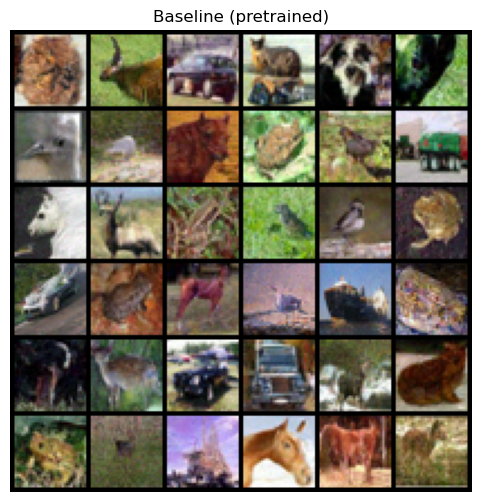

In [6]:
@torch.no_grad()
def sample_pretrained(pipe, num=36, steps=250):
    """Sample from the pretrained model for qualitative visualization."""
    out = pipe(batch_size=num, num_inference_steps=steps)
    arr = []
    for im in out.images:
        arr.append(torch.from_numpy(np.array(im).astype("float32")/255.0).permute(2,0,1))
    return torch.stack(arr, dim=0)

baseline_imgs = sample_pretrained(pipe, num=cfg.n_final_samples, steps=250)
show_grid_tensor(baseline_imgs, "Baseline (pretrained)")


## Paper watermark x_A: bottom‑right **box** (single channel)

Fourier watermark → xA set on channel 1 | mean: 6.208817349140361e-10 | rms: 0.5774433612823486


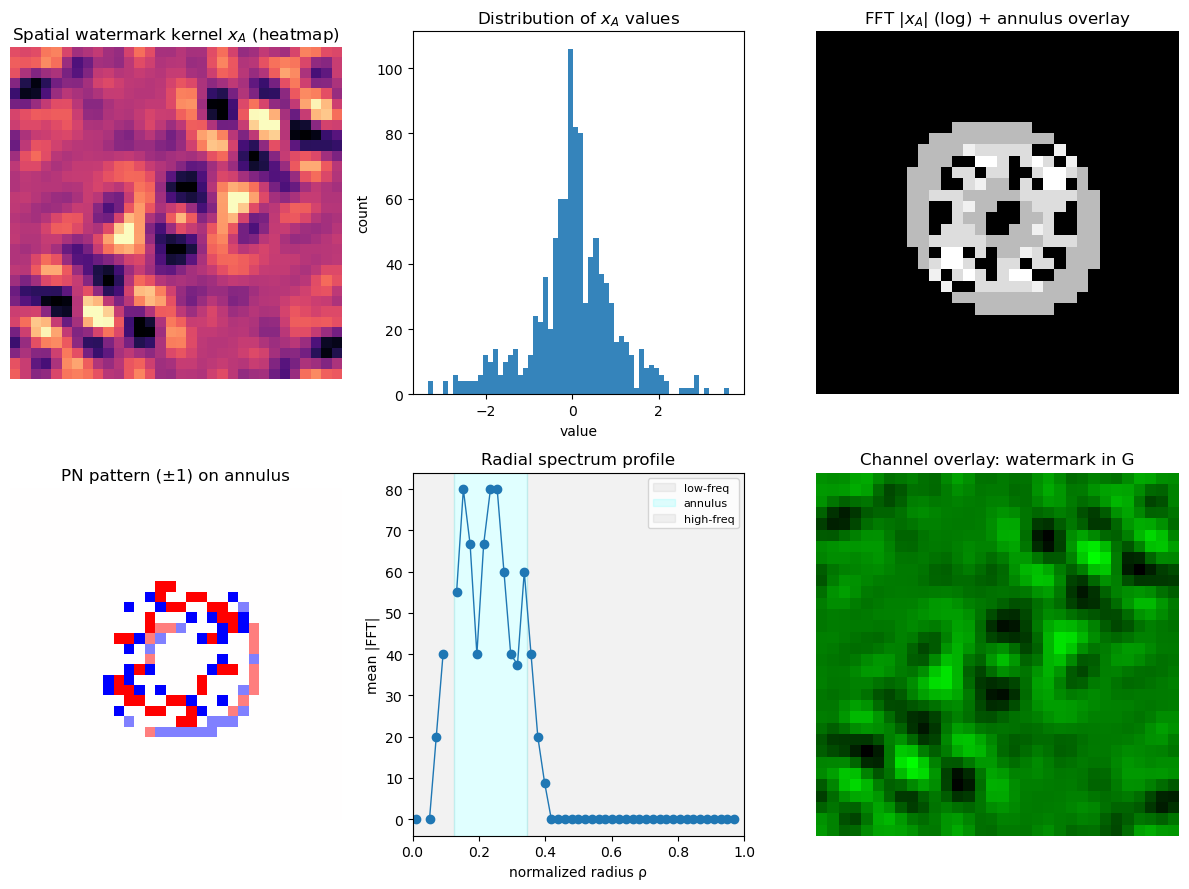

xA stats — mean=5.5879e-09, std=1.0000, min=-3.342, max=3.624
Annulus coverage: 172 / 1024 pixels (16.8%)


In [7]:
# ========== Fourier watermark (mid-band annulus PN → spatial xA) ==========
import numpy as np
import torch

def _annulus_mask(H, W, rmin=0.12, rmax=0.35):
    yy, xx = np.mgrid[-H//2:H-H//2, -W//2:W-W//2]
    rr = np.sqrt(yy**2 + xx**2)
    rmax_nyq = 0.5*np.sqrt(H**2 + W**2)  # Nyquist radius in pixels
    ρ = rr / rmax_nyq                    # normalized radius ∈ [0,1]
    M = (ρ >= rmin) & (ρ <= rmax)
    return M

def build_fourier_watermark_spatial(H, W, *, rmin=0.12, rmax=0.35, seed=0, lam=1.0):
    """
    Returns:
      xA_spatial: [H,W] float32, zero-mean, unit-norm-ish spatial watermark pattern
      PN:         [H,W] float32, ±1 chips in annulus (for detection)
      M:          [H,W] bool mask for the annulus
    """
    rng = np.random.default_rng(seed)
    M = _annulus_mask(H, W, rmin, rmax)

    # ±1 PN only inside annulus; 0 elsewhere
    PN = np.zeros((H, W), dtype=np.float32)
    PN[M] = rng.integers(0, 2, size=M.sum()).astype(np.float32)*2 - 1

    # Enforce Hermitian symmetry so the IFFT is (approximately) real
    PN = 0.5 * (PN + np.flipud(np.fliplr(PN)))

    # Put PN into Fourier magnitude as an additive "shape", keep zero phase.
    # We just need a spatial kernel whose FFT has the PN support; simple: inverse FFT of PN.
    F = np.fft.ifftshift(PN * lam)  # scale with lam; small lam produces low-energy kernel
    xA = np.fft.ifft2(F).real.astype(np.float32)

    # Normalize to zero-mean and unit L2 so your existing time-scaling (f2, dyn_scale) controls energy
    xA -= xA.mean()
    norm = np.sqrt((xA**2).mean()) + 1e-8
    xA /= norm
    return xA, PN, M

# ---- Build xA for your chosen channel (keeps your injection code intact) ----
H = W = cfg.image_size
channels = cfg.channels

WTMK_CH = 0 if channels == 1 else int(cfg.which_channel_rgb)

xA_sp, PN, ANNULUS = build_fourier_watermark_spatial(
    H, W, rmin=0.12, rmax=0.35, seed=42, lam=1.0
)
xA = torch.zeros(channels, H, W, dtype=torch.float32, device=device)
xA[WTMK_CH] = torch.from_numpy(xA_sp).to(device)

print("Fourier watermark → xA set on channel", WTMK_CH, "| mean:", float(xA.mean()), "| rms:", float(xA.std()))


assert 'xA' in globals() and 'PN' in globals() and 'ANNULUS' in globals()

# 1) Spatial kernel placed into channel WTMK_CH
xA_ch = xA[WTMK_CH].detach().cpu().numpy().astype(np.float32)   # [H,W]
H, W = xA_ch.shape

# 2) Spectrum of the spatial kernel
F = np.fft.fftshift(np.fft.fft2(xA_ch))
mag = np.abs(F).astype(np.float32)
mag_log = np.log1p(mag)  # log for visibility

# 3) PN limited to the annulus
PN_vis = PN.copy()
PN_vis[~ANNULUS] = 0.0

# 4) Small radial profile (for curiosity)
yy, xx = np.mgrid[-H//2:H-H//2, -W//2:W-W//2]
rr = np.sqrt(yy**2 + xx**2)
rmax_nyq = 0.5*np.sqrt(H**2 + W**2)
rho = rr / rmax_nyq   # normalized radius in [0,1]
bins = np.linspace(0, 1.0, 50)
rad_prof = []
for i in range(len(bins)-1):
    m = (rho >= bins[i]) & (rho < bins[i+1])
    if m.any():
        rad_prof.append(mag[m].mean())
    else:
        rad_prof.append(np.nan)
rad_prof = np.array(rad_prof, dtype=np.float32)

# 5) If RGB, show which channel carries the watermark
def _channel_overlay(box: np.ndarray, ch: int):
    rgb = np.zeros((H, W, 3), dtype=np.float32)
    if xA.shape[0] == 3:
        rgb[..., ch] = (box - box.min()) / (box.max() - box.min() + 1e-6)
    else:
        rgb[..., :] = (box - box.min()) / (box.max() - box.min() + 1e-6)
    return rgb

# ---- Plot ----
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 3, width_ratios=[1,1,1.1])

# (a) Spatial kernel heatmap
ax = fig.add_subplot(gs[0,0])
v = np.percentile(xA_ch, [1, 99])
ax.imshow(xA_ch, cmap='magma', vmin=v[0], vmax=v[1])
ax.set_title("Spatial watermark kernel $x_A$ (heatmap)")
ax.axis('off')

# (b) Histogram of spatial values (zero-mean, ~unit RMS)
ax = fig.add_subplot(gs[0,1])
ax.hist(xA_ch.flatten(), bins=60, alpha=0.9)
ax.set_title("Distribution of $x_A$ values")
ax.set_xlabel("value")
ax.set_ylabel("count")

# (c) Spectrum magnitude (log) with annulus overlay
ax = fig.add_subplot(gs[0,2])
ax.imshow(mag_log, cmap='gray')
# overlay annulus boundary (thin)
ann = ANNULUS.astype(np.uint8)
contour = np.logical_xor(ann, np.pad(ann, 1)[1:-1,1:-1])  # cheap edge
ys, xs = np.where(contour)
ax.plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
ax.set_title("FFT |$x_A$| (log) + annulus overlay")
ax.axis('off')

# (d) PN on annulus (±1, zero elsewhere)
ax = fig.add_subplot(gs[1,0])
ax.imshow(PN_vis, cmap='bwr', vmin=-1, vmax=1)
ax.set_title("PN pattern (±1) on annulus")
ax.axis('off')

# (e) Radial profile of spectrum magnitude
ax = fig.add_subplot(gs[1,1])
centers = 0.5*(bins[:-1] + bins[1:])
ax.plot(centers, rad_prof, marker='o', lw=1)
ax.axvspan(0, np.min(rho[ANNULUS]), color='k', alpha=0.05, label='low-freq')
ax.axvspan(np.min(rho[ANNULUS]), np.max(rho[ANNULUS]), color='cyan', alpha=0.12, label='annulus')
ax.axvspan(np.max(rho[ANNULUS]), 1.0, color='k', alpha=0.05, label='high-freq')
ax.set_xlim(0, 1.0)
ax.set_xlabel("normalized radius ρ")
ax.set_ylabel("mean |FFT|")
ax.set_title("Radial spectrum profile")
ax.legend(fontsize=8, loc='upper right')

# (f) Channel overlay (which channel carries xA)
ax = fig.add_subplot(gs[1,2])
overlay = _channel_overlay(xA_ch, WTMK_CH)
ax.imshow(overlay)
if xA.shape[0] == 3:
    ch_name = {0:'R', 1:'G', 2:'B'}.get(WTMK_CH, str(WTMK_CH))
    ax.set_title(f"Channel overlay: watermark in {ch_name}")
else:
    ax.set_title("Grayscale overlay")
ax.axis('off')

plt.tight_layout()
plt.show()

# Quick numeric summary
print(f"xA stats — mean={xA_ch.mean():.4e}, std={xA_ch.std():.4f}, min={xA_ch.min():.3f}, max={xA_ch.max():.3f}")
print(f"Annulus coverage: {ANNULUS.sum()} / {H*W} pixels ({100.0*ANNULUS.mean():.1f}%)")


## Building the time-dependent watermark weights

In here, we construct the **time ramp** and **scales** that decide *how strongly* the watermark contributes at each diffusion step. It does **not** inject the watermark yet.

### 1) Schedule-aware weight per step
We define
$$
h_t \;=\; \frac{1-\alpha_t}{\sqrt{\,1-\bar{\alpha}_t\,}},
$$
where $\alpha_t=1-\beta_t$ and $\bar{\alpha}_t=\prod_{s=1}^{t}\alpha_s$.  
Intuition: $1-\alpha_t$ is the variance newly added at step $t$; dividing by $\sqrt{1-\bar{\alpha}_t}$ normalizes by the current noise scale so the weight is comparable across timesteps.

### 2) A monotone ramp that peaks at $t_A$
We accumulate and normalize:
$$
\text{cumsum}_h(t)=\sum_{s=0}^{t} h_s, \qquad
K \;=\; \Big(\sum_{s=0}^{t_A} h_s\Big)^{-1}, \qquad
f_2(t) \;=\; K \cdot \text{cumsum}_h(t).
$$
By construction, $f_2(t_A)\approx 1$. This makes $f_2(t)$ a smooth, increasing ramp from near 0 to 1 as $t$ approaches $t_A$.

### 3) Match the watermark to the noise level
We also use
$$
\text{dyn\_scale}(t) \;=\; \sqrt{\,1-\bar{\alpha}_t\,},
$$
so the watermark magnitude tracks the step’s noise scale. The **time-shaped watermark** used later is
$$
b_t \;=\; f_2(t)\,\text{dyn\_scale}(t)\,x_A.
$$

### 4) Centering term and broadcasting helper
We keep
$$
b_0 \;=\; f_2(0)\,x_A,
$$
which appears in the centered bias $(b_t - \sqrt{\bar{\alpha}_t}\,b_0)$ used during embedding; this prevents a drifting offset across $t$. The small `gather` helper simply picks values like $f_2(t)$ or $\text{dyn\_scale}(t)$ for each sample’s timestep and reshapes them to broadcast over a batch of images.

**Takeaway.**  
- $x_A$ (the mask) decides the **where/shape**.  
- $f_2(t)$, $\text{dyn\_scale}(t)$, and $K$ decide the **time profile** so the watermark ramps up and is strongest near $t_A$.  
- $b_0$ ensures the injected bias is properly centered at each step.


In [8]:
# =============================================
# ✅ Build watermark weighting schedule (cleaned)
# =============================================

# --- 1. Per-timestep "noise weight" ---
# h_t ≈ (1 - α_t) / √(1 - ᾱ_t)
# - (1 - α_t): how much noise is added at step t
# - √(1 - ᾱ_t): total noise level accumulated up to t
# This gives a schedule-aware weight that grows as noise injection grows.
h = (1 - alpha) / torch.clamp((1 - a_bar), min=1e-12).sqrt()   # [T]

# --- 2. Cumulative ramp (optional) ---
# Accumulate h_t over time to build a smooth ramp.
# Instead of hard-coding a custom function, we just integrate this signal.
cumsum_h = torch.cumsum(h, dim=0)                              # [T]

# --- 3. Normalize ramp to ~1 at t_A ---
# Ensures that by the time we reach t_A, the watermark strength ≈ 1.0
# This keeps the signal strength predictable even if T or t_A changes.
K = 1.0 / float(cumsum_h[tA].item())                           # scalar
f2 = K * cumsum_h                                             # [T]

# 🔧 SIMPLIFIED VERSION (optional): 
# If you don't care about ramp shaping and want constant injection,
# comment the above and just use:
# f2 = torch.ones_like(a_bar)

# --- 4. Noise matching term ---
# dyn_scale(t) = √(1 - ᾱ_t)
# Scales watermark energy to match the natural noise level at each step.
# Ensures the watermark isn’t too strong early or too weak late.
dyn_scale = sqrt_1m_a_bar                                      # [T]

# --- 5. Helper: gather scalar coefficients for batch timesteps ---
# This utility selects per-sample values from [T]-length schedules and reshapes
# them into [B,1,1,1] for broadcasting with [B,C,H,W] tensors.
def gather(arr, t): 
    return arr.index_select(0, t).view(-1, 1, 1, 1)

# --- 6. Initial watermark reference term (b₀) ---
# b₀ = f₂(0) * x_A
# This is used in the centering term: (b_t - √ᾱ_t * b₀)
# It stabilizes the cumulative injection and prevents unwanted drift.
b0 = f2[0] * xA                                               # [C,H,W]

# ✅ Sanity check — f₂[tA] should be ≈ 1.0 by construction
print(f"Normalization constant K = {float(K):.6f}")
print(f"f2[tA] ≈ {float(f2[tA]):.4f} (should be ~1.0)")

Normalization constant K = 0.142318
f2[tA] ≈ 1.0000 (should be ~1.0)


## Mid-chain watermark check at $t_A$ — baseline vs. injected (diagnostic)

**Purpose.** This cell compares two ways of looking for the watermark **at the diffusion midpoint $t_A$**:

1. **Baseline (no injection):** sample many clean trajectories from the pretrained model, stop at $t_A$, **average** them to suppress noise, and visualize/measure any residual box signal.  
2. **Injected (diagnostic):** run the same sampler but **actively add** the watermark bias during steps $t \le t_A$ (for inspection only), then stop at $t_A$ and average. This helps you see what a “strong” watermark would look like at the right time.

---

### What gets captured and why we average
- We capture $x_{t_A}$ from **many** independent runs and compute the average $\bar{x}_{t_A}$.  
- The watermark is a **tiny mean shift**; averaging $N$ paths boosts the SNR by $\sqrt{N}$, revealing the pattern statistically while random noise cancels.

---

### The diagnostic injection used here (only for the *injected* view)
At each step $t \le t_A$ we add a small bias
$$
\Delta_t \;=\; (1-\gamma)\,\bigl(b_t - \sqrt{\bar{\alpha}_t}\,b_0\bigr),\qquad
b_t \;=\; f_2(t)\,\sqrt{1-\bar{\alpha}_t}\;x_A,\quad b_0=f_2(0)\,x_A,
$$
where:
- $x_A$ is the fixed spatial mask (bottom-right box in the chosen channel).  
- $f_2(t)$ is a ramp normalized so $f_2(t_A)\approx 1$.  
- $\bar{\alpha}_t=\prod_{s\le t}\alpha_s$ comes from the DDPM schedule.  
- $\gamma\in(0,1]$ controls watermark strength (smaller $\gamma$ ⇒ stronger watermark).

> **Note:** This diagnostic **does not reflect paper-exact sampling**. It’s just a visualization aid. For final verification, use the **fine-tuned model** with **no injection** and average at $t_A$.

---

### Visuals produced
- **RGB average** of $\bar{x}_{t_A}$ for baseline and injected.  
- **Watermark channel heatmap** for each (auto-contrast).  
- **Overlay with the ground-truth box** to see alignment.

---

### Metrics reported
- **Contour distance** (lower is better): Hu-moment shape distance between the largest edge in the averaged heatmap and the box contour (computed in the ROI).  

Typical interpretation:

- Baseline: higher contour distance.
- Injected (diagnostic): lower contour distance.

**Reminder:** The final images $x_0$ are not meant to show a very visible patch; the watermark is designed to be **statistically detectable near $t_A$**, not perceptually obvious.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


[Baseline]    Spectral correlation: -0.0454
[Watermarked] Spectral correlation: 0.0166


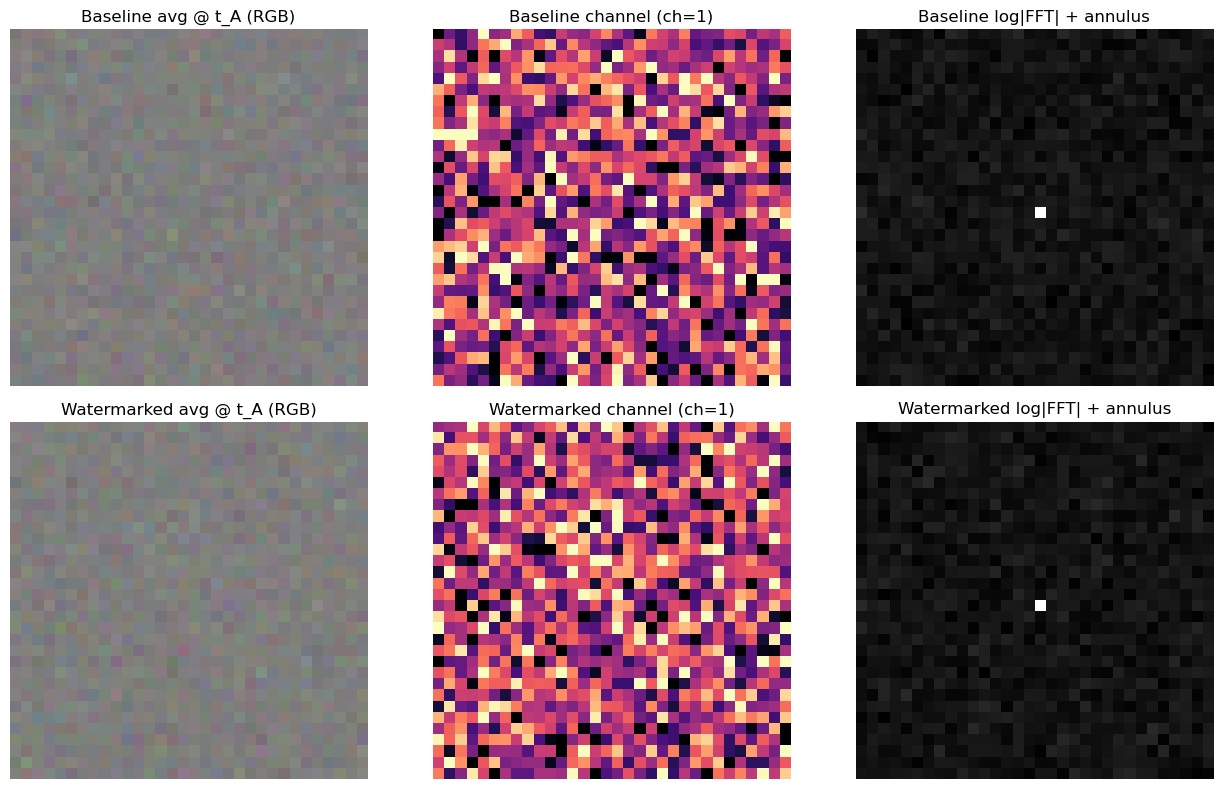

In [9]:
# Load a CLEAN, pretrained DDPM pipeline (no watermark) to produce the baseline.
# - The pipeline bundles a UNet ε-predictor and a scheduler with the training noise schedule.
baseline_pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
baseline_unet = baseline_pipe.unet
baseline_sched: DDPMScheduler = baseline_pipe.scheduler

# ----------------------------------------------------------------------
# Utility: clamp [0,1] → uint8 [0,255] (CPU)
# ----------------------------------------------------------------------
def _to_u8_0_255(x01: torch.Tensor) -> torch.Tensor:
    return (x01.clamp(0,1) * 255).to(torch.uint8).cpu()

# ----------------------------------------------------------------------
# Paper-exact sampler (NO injection during sampling)
# - Optionally capture x_{t_A} and always divide outputs by gamma (f1(t)=0)
# ----------------------------------------------------------------------
@torch.no_grad()
def sample_paper(unet_like, scheduler_like, n=36, steps=1000, capture_tA=None, gamma=0.8):
    """
    Standard reverse diffusion with 'steps' sampling steps.
    If capture_tA is provided (training index), also return the mid-state near t_A.
    For f1(t)=0 training, undo gamma at the end.

    Returns:
      final_imgs, mid_imgs (both in [0,1]); mid_imgs=None if capture_tA is None
    """
    unet_like.eval()
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps  # descending training indices

    x = torch.randn(n, channels, H, W, device=device)

    x_tA = None
    cap_idx = None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs()
        cap_idx = int(torch.argmin(diffs).item())

    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if cap_idx is not None and i == cap_idx:
            x_tA = x.clone()

    # Undo gamma scaling (f1=0) and map to [0,1]
    x = (x / gamma)
    if x_tA is not None:
        x_tA = (x_tA / gamma)

    x = ((x.clamp(-1, 1) + 1) * 0.5).detach()
    if x_tA is not None:
        x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x, x_tA

@torch.no_grad()
def _generate_u8(unet_like, scheduler_like, n: int, steps: int, gamma: float) -> torch.Tensor:
    """Generate ~n samples with paper-exact sampler; float [0,1] -> uint8 [0,255]."""
    bs, out, left = min(256, n), [], n
    while left > 0:
        cur = min(bs, left)
        imgs, _ = sample_paper(unet_like, scheduler_like, n=cur, steps=steps, capture_tA=None, gamma=gamma)
        out.append(_to_u8_0_255(imgs))  # [cur,C,H,W] uint8 (CPU)
        left -= cur
    gen_u8 = torch.cat(out, dim=0)[:n]
    return gen_u8

# ----------------------------------------------------------------------
# Helper: sample ONLY the mid-state at t_A (paper-exact; divide by gamma)
# ----------------------------------------------------------------------
@torch.no_grad()
def _sample_mid_after(unet_like, scheduler_like, n=128, steps=1000, capture_tA=None, gamma=0.8):
    """Return batch of mid-states at t_A in [0,1] using paper-exact sampling."""
    assert capture_tA is not None
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    x_tA = (x_tA / cfg.gamma)
    x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x_tA  # [N,C,H,W] in [0,1]

# ----------------------------------------------------------------------
# Baseline mid-state @ t_A (no watermark) for comparison
# ----------------------------------------------------------------------
xmid_base = _sample_mid_after(baseline_unet, baseline_sched,
                              n=cfg.verify_batch_size, steps=cfg.sample_steps,
                              capture_tA=tA, gamma=cfg.gamma)
xavg_base = xmid_base.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]
ch_base   = xavg_base[0, WTMK_CH].cpu().numpy()
lo_b, hi_b = np.percentile(ch_base, [5, 95])  # auto-contrast for heatmaps

# ----------------------------------------------------------------------
# Diagnostic sampler **with Fourier injection** (for visualization only)
# Mirrors the spectral modulation you use during training for t <= t_A.
# ----------------------------------------------------------------------
import numpy as np

@torch.no_grad()
def sample_mid_with_fourier_injection(unet_like, scheduler_like,
                                      n=128, steps=cfg.sample_steps,
                                      capture_tA=tA, gamma=cfg.gamma, lam_clip=0.02):
    """
    Diagnostic sampler: at t <= t_A, apply small multiplicative magnitude modulation
    on the watermark channel in FFT: |F| <- |F| * (1 + λ_t * PN) on ANNULUS.
    This is for *visual confirmation*; paper-exact sampling does NOT inject.
    """
    assert PN is not None and ANNULUS is not None
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    def _spectral_mod_one(x_hw: np.ndarray, lam: float) -> np.ndarray:
        Xi = np.fft.fftshift(np.fft.fft2(x_hw))
        mag, ph = np.abs(Xi), np.angle(Xi)
        gain = 1.0 + np.clip(lam, -lam_clip, lam_clip) * PN  # PN zero outside annulus
        mag2 = mag * gain
        Xi2 = np.fft.ifftshift(mag2 * np.exp(1j*ph))
        return np.fft.ifft2(Xi2).real.astype(np.float32)

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, tt in enumerate(timesteps):
        t_idx = int(tt.item())
        if t_idx <= capture_tA:
            # Time-shaped small gain: (1-γ) * f2(t)
            lam_t = float(((1.0 - gamma) * f2[t_idx]).clamp(min=0.0).item())
            # apply ONLY to the watermark channel
            x_np = x[:, WTMK_CH].detach().cpu().numpy().astype(np.float32)
            for k in range(x_np.shape[0]):
                x_np[k] = _spectral_mod_one(x_np[k], lam=lam_t)
            x[:, WTMK_CH] = torch.from_numpy(x_np).to(x.device)

        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    # Undo gamma (f1=0) and map to [0,1]
    x_tA = (x_tA / gamma)
    x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x_tA

xmid_inj = sample_mid_with_fourier_injection(baseline_unet, baseline_sched,
                                             n=cfg.verify_batch_size, steps=cfg.sample_steps,
                                             capture_tA=tA, gamma=cfg.gamma)
xavg_inj = xmid_inj.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]

# ----------------------------------------------------------------------
# Frequency-domain detection (correlation on the annulus)
# ----------------------------------------------------------------------
def spectral_correlation_score(x01_chw: torch.Tensor, PN: np.ndarray, M: np.ndarray) -> float:
    """
    x01_chw: [C,H,W] in [0,1]; check WTMK_CH channel
    PN: [H,W] ±1, M: [H,W] bool annulus
    return: correlation in [-1,1] (higher = stronger watermark)
    """
    x = x01_chw[WTMK_CH].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    mag = np.abs(F).astype(np.float32)
    vals = mag[M]
    if vals.size < 16:
        return 0.0
    z = (vals - vals.mean()) / (vals.std() + 1e-6)
    p = PN[M]
    p = (p - p.mean()) / (p.std() + 1e-6)
    return float((z * p).mean())

score_base = spectral_correlation_score(xavg_base[0], PN, ANNULUS)
score_wtmk = spectral_correlation_score(xavg_inj[0],  PN, ANNULUS)

print(f"[Baseline]    Spectral correlation: {score_base:.4f}")
print(f"[Watermarked] Spectral correlation: {score_wtmk:.4f}")

# ----------------------------------------------------------------------
# Visualization: spatial average + spectrum with annulus overlay
# ----------------------------------------------------------------------
import matplotlib.pyplot as plt

def _fft_log_with_annulus(x01_chw: torch.Tensor, ch: int):
    x = x01_chw[ch].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    mag_log = np.log1p(np.abs(F).astype(np.float32))
    return mag_log

mag_base = _fft_log_with_annulus(xavg_base[0], WTMK_CH)
mag_wtmk = _fft_log_with_annulus(xavg_inj[0],  WTMK_CH)

# quick annulus edge for overlay
ann = ANNULUS.astype(np.uint8)
edge = np.logical_xor(ann, np.pad(ann, 1)[1:-1,1:-1])

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

# Row 1: Baseline
axes[0,0].imshow(xavg_base[0].permute(1,2,0).cpu().numpy()); axes[0,0].set_title("Baseline avg @ t_A (RGB)"); axes[0,0].axis("off")
axes[0,1].imshow(ch_base, cmap="magma", vmin=lo_b, vmax=hi_b); axes[0,1].set_title(f"Baseline channel (ch={WTMK_CH})"); axes[0,1].axis("off")
axes[0,2].imshow(mag_base, cmap="gray"); 
ys, xs = np.where(edge); axes[0,2].plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
axes[0,2].set_title("Baseline log|FFT| + annulus"); axes[0,2].axis("off")

# Row 2: Watermarked (diagnostic Fourier injection)
ch_wtmk = xavg_inj[0, WTMK_CH].cpu().numpy()
lo_w, hi_w = np.percentile(ch_wtmk, [5, 95])
axes[1,0].imshow(xavg_inj[0].permute(1,2,0).cpu().numpy()); axes[1,0].set_title("Watermarked avg @ t_A (RGB)"); axes[1,0].axis("off")
axes[1,1].imshow(ch_wtmk, cmap="magma", vmin=lo_w, vmax=hi_w); axes[1,1].set_title(f"Watermarked channel (ch={WTMK_CH})"); axes[1,1].axis("off")
axes[1,2].imshow(mag_wtmk, cmap="gray"); 
ys, xs = np.where(edge); axes[1,2].plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
axes[1,2].set_title("Watermarked log|FFT| + annulus"); axes[1,2].axis("off")

plt.tight_layout()
plt.show()

Running fine-tuning sweep (all layers) + attacks…
=== finetune_and_report start (max_steps=0) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 0 steps: 0it [00:04, ?it/s]


[DONE] 3) Run fine-tuning in 5.07s (cumulative 5.11s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 105.81s (cumulative 110.92s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 17.82s (cumulative 128.75s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1014.42s (cumulative 1143.17s)

[STEP] 7) Build summary figure ...


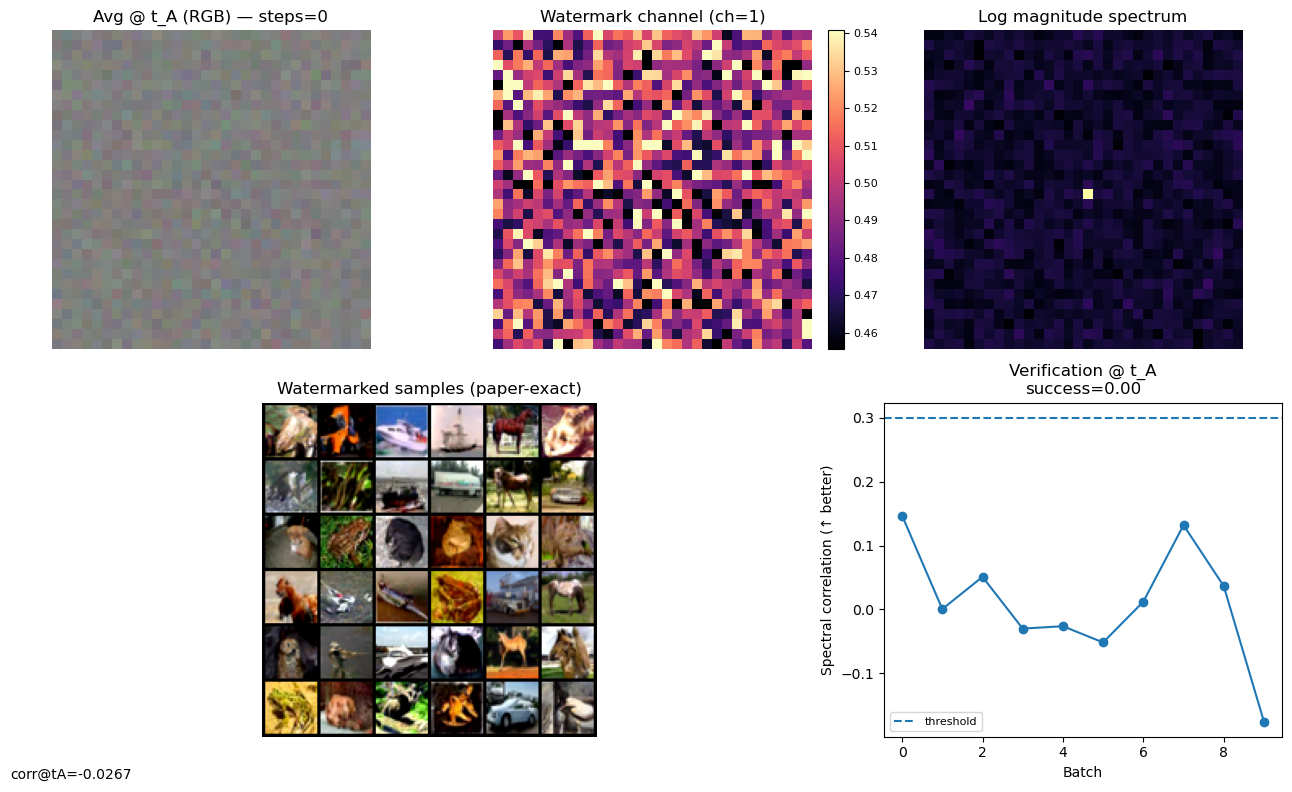

[DONE] 7) Build summary figure in 0.24s (cumulative 1143.41s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 812.34s (cumulative 1955.75s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 1955.76s)

=== finetune_and_report done in 1955.76s ===
=== finetune_and_report start (max_steps=100) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 100 steps: 100%|██████████| 100/100 [00:35<00:00,  2.85it/s, loss=0.0558]


[DONE] 3) Run fine-tuning in 35.47s (cumulative 35.51s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.14s (cumulative 135.65s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.65s (cumulative 152.30s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1001.61s (cumulative 1153.92s)

[STEP] 7) Build summary figure ...


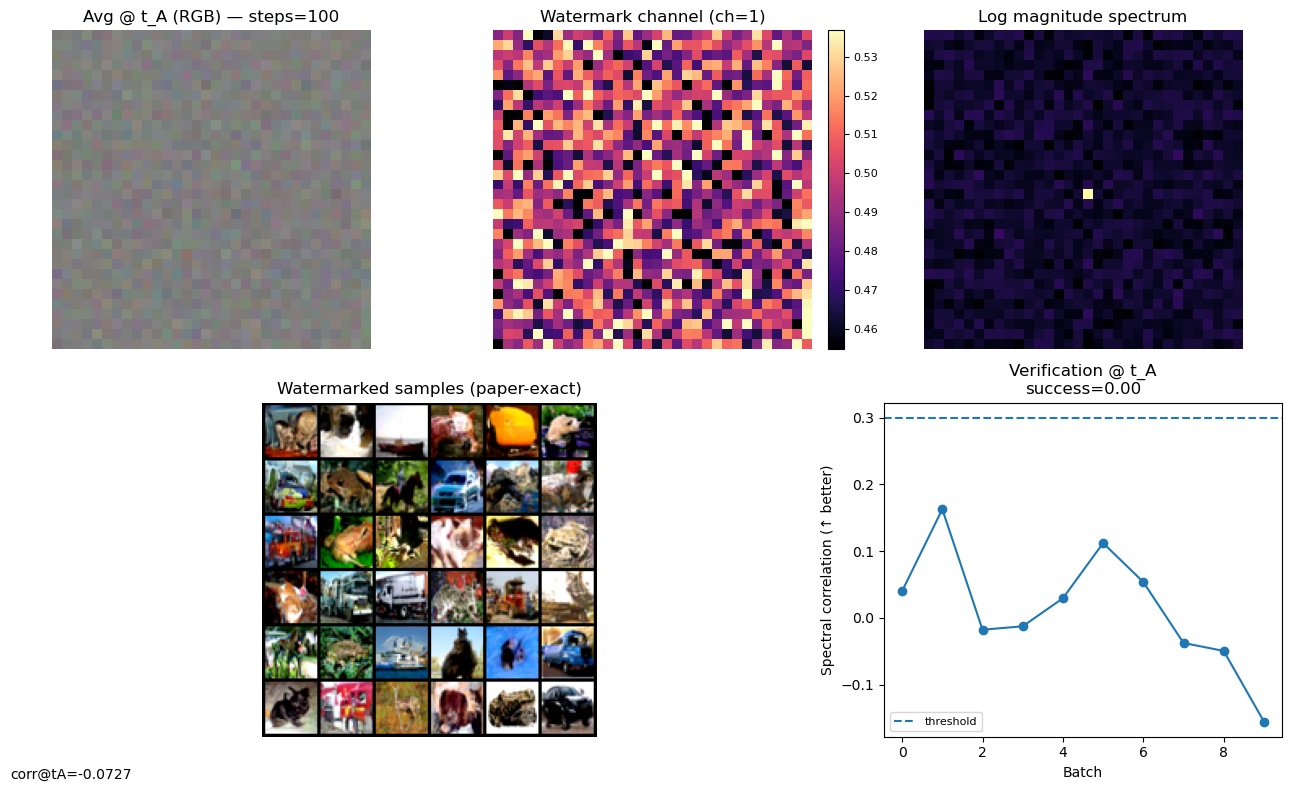

[DONE] 7) Build summary figure in 0.28s (cumulative 1154.19s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 812.84s (cumulative 1967.03s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 1967.04s)

=== finetune_and_report done in 1967.04s ===
=== finetune_and_report start (max_steps=200) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 200 steps: 100%|██████████| 200/200 [01:02<00:00,  3.21it/s, loss=0.0471]


[DONE] 3) Run fine-tuning in 62.72s (cumulative 62.76s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.10s (cumulative 162.86s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.92s (cumulative 179.79s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1000.77s (cumulative 1180.56s)

[STEP] 7) Build summary figure ...


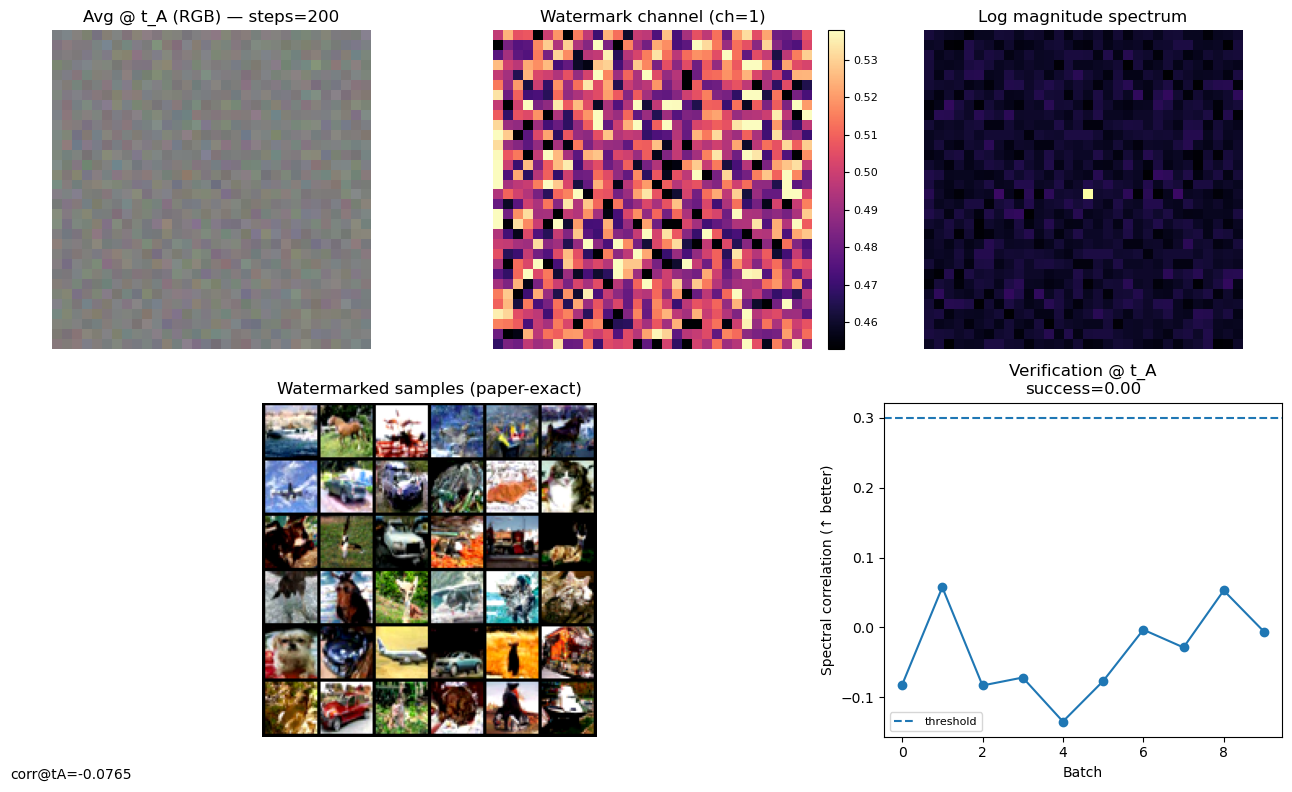

[DONE] 7) Build summary figure in 0.22s (cumulative 1180.79s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 812.10s (cumulative 1992.88s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 1992.88s)

=== finetune_and_report done in 1992.88s ===
=== finetune_and_report start (max_steps=300) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 300 steps: 100%|██████████| 300/300 [01:37<00:00,  3.08it/s, loss=0.0655]


[DONE] 3) Run fine-tuning in 97.59s (cumulative 97.63s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.16s (cumulative 197.79s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.59s (cumulative 214.38s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1002.32s (cumulative 1216.70s)

[STEP] 7) Build summary figure ...


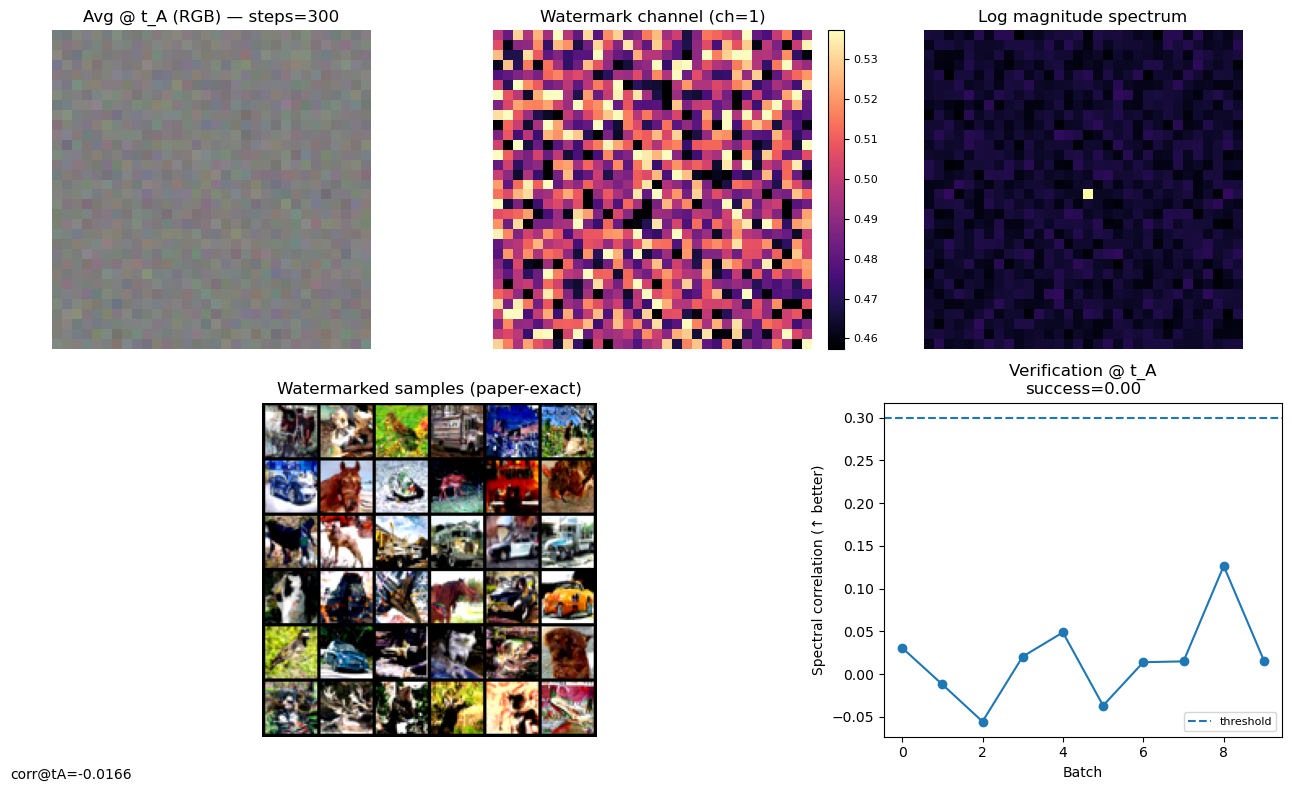

[DONE] 7) Build summary figure in 0.24s (cumulative 1216.94s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 814.24s (cumulative 2031.18s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2031.18s)

=== finetune_and_report done in 2031.18s ===
=== finetune_and_report start (max_steps=500) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.05s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 500 steps: 100%|██████████| 500/500 [02:37<00:00,  3.17it/s, loss=0.0762]


[DONE] 3) Run fine-tuning in 158.25s (cumulative 158.30s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.40s (cumulative 258.69s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 17.27s (cumulative 275.97s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1003.92s (cumulative 1279.89s)

[STEP] 7) Build summary figure ...


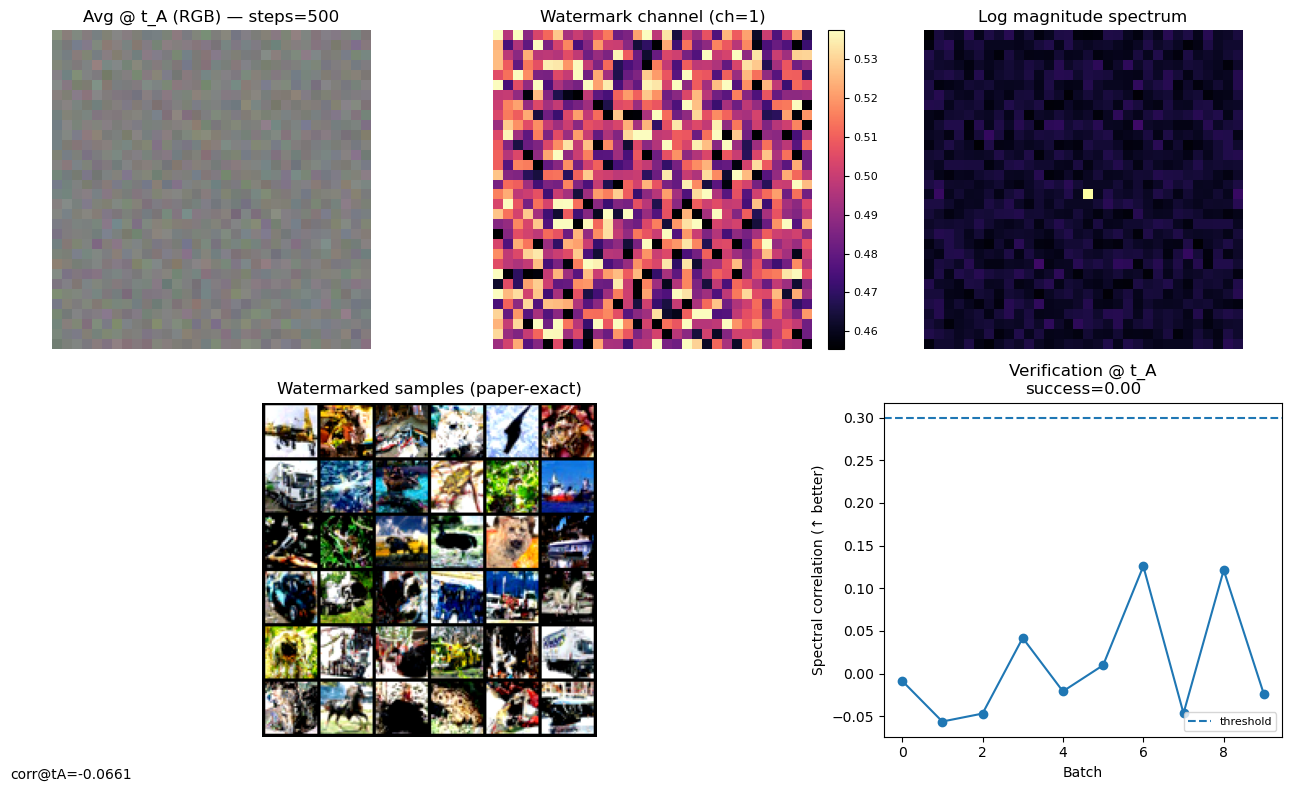

[DONE] 7) Build summary figure in 0.24s (cumulative 1280.14s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 815.15s (cumulative 2095.29s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2095.29s)

=== finetune_and_report done in 2095.29s ===
=== finetune_and_report start (max_steps=1000) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 1000 steps: 100%|██████████| 1000/1000 [05:09<00:00,  3.23it/s, loss=0.0201]


[DONE] 3) Run fine-tuning in 309.66s (cumulative 309.70s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.36s (cumulative 410.06s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 17.18s (cumulative 427.24s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1004.00s (cumulative 1431.24s)

[STEP] 7) Build summary figure ...


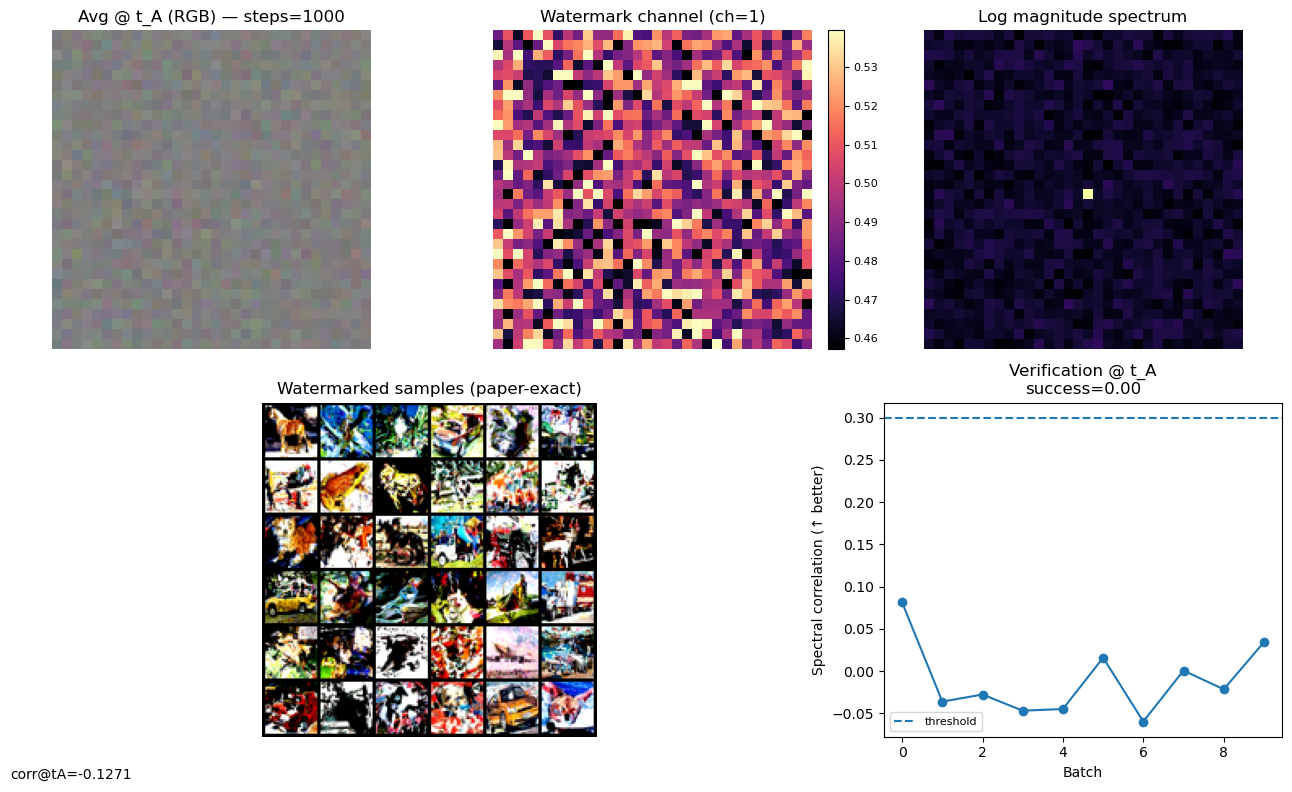

[DONE] 7) Build summary figure in 0.25s (cumulative 1431.49s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 815.28s (cumulative 2246.77s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2246.77s)

=== finetune_and_report done in 2246.77s ===


,max_steps,spectral_corr_tA,verify_success,IS,FID,Precision,Recall
0,0,-0.026676,0.0,None,36.817684,0.703125,0.611816
1,100,-0.072670,0.0,None,40.711338,0.683594,0.604492
2,200,-0.076546,0.0,None,48.776142,0.644531,0.583008
3,300,-0.016577,0.0,None,56.099857,0.600586,0.539062
4,500,-0.066093,0.0,None,75.824173,0.547363,0.467773
5,1000,-0.127106,0.0,None,118.332436,0.515625,0.324219


Running fine-tuning sweep (last block only) + attacks…
=== finetune_and_report start (max_steps=0) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.05s (cumulative 0.05s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 0 steps: 0it [00:04, ?it/s]


[DONE] 3) Run fine-tuning in 5.54s (cumulative 5.59s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.18s (cumulative 105.77s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.68s (cumulative 122.45s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 998.16s (cumulative 1120.61s)

[STEP] 7) Build summary figure ...


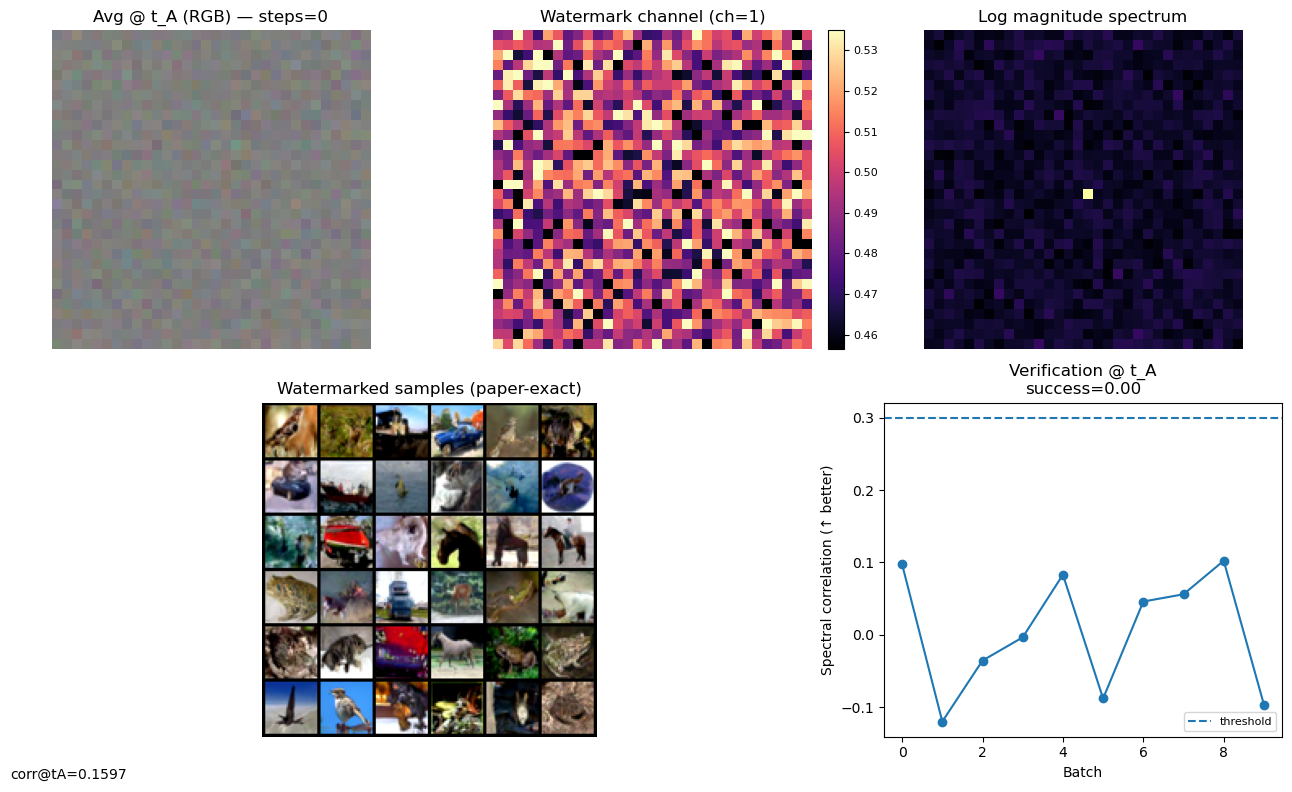

[DONE] 7) Build summary figure in 0.24s (cumulative 1120.86s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 810.93s (cumulative 1931.79s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 1931.79s)

=== finetune_and_report done in 1931.79s ===
=== finetune_and_report start (max_steps=100) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 100 steps: 100%|██████████| 100/100 [00:24<00:00,  4.00it/s, loss=0.0738]


[DONE] 3) Run fine-tuning in 25.32s (cumulative 25.36s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 100.18s (cumulative 125.54s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.83s (cumulative 142.36s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1001.25s (cumulative 1143.62s)

[STEP] 7) Build summary figure ...


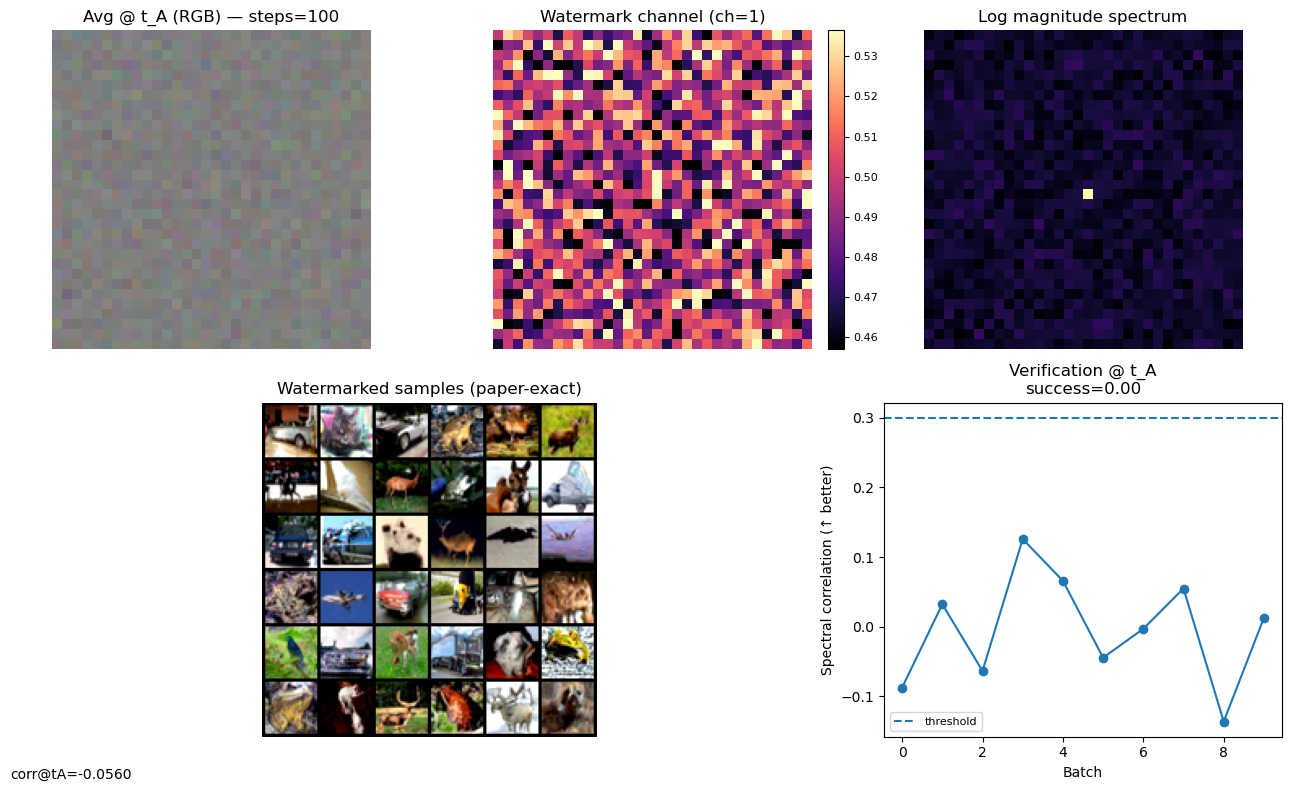

[DONE] 7) Build summary figure in 0.25s (cumulative 1143.87s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 813.40s (cumulative 1957.27s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 1957.27s)

=== finetune_and_report done in 1957.27s ===
=== finetune_and_report start (max_steps=200) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 200 steps: 100%|██████████| 200/200 [00:46<00:00,  4.28it/s, loss=0.113] 


[DONE] 3) Run fine-tuning in 47.15s (cumulative 47.18s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 99.80s (cumulative 146.99s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.78s (cumulative 163.77s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1040.90s (cumulative 1204.67s)

[STEP] 7) Build summary figure ...


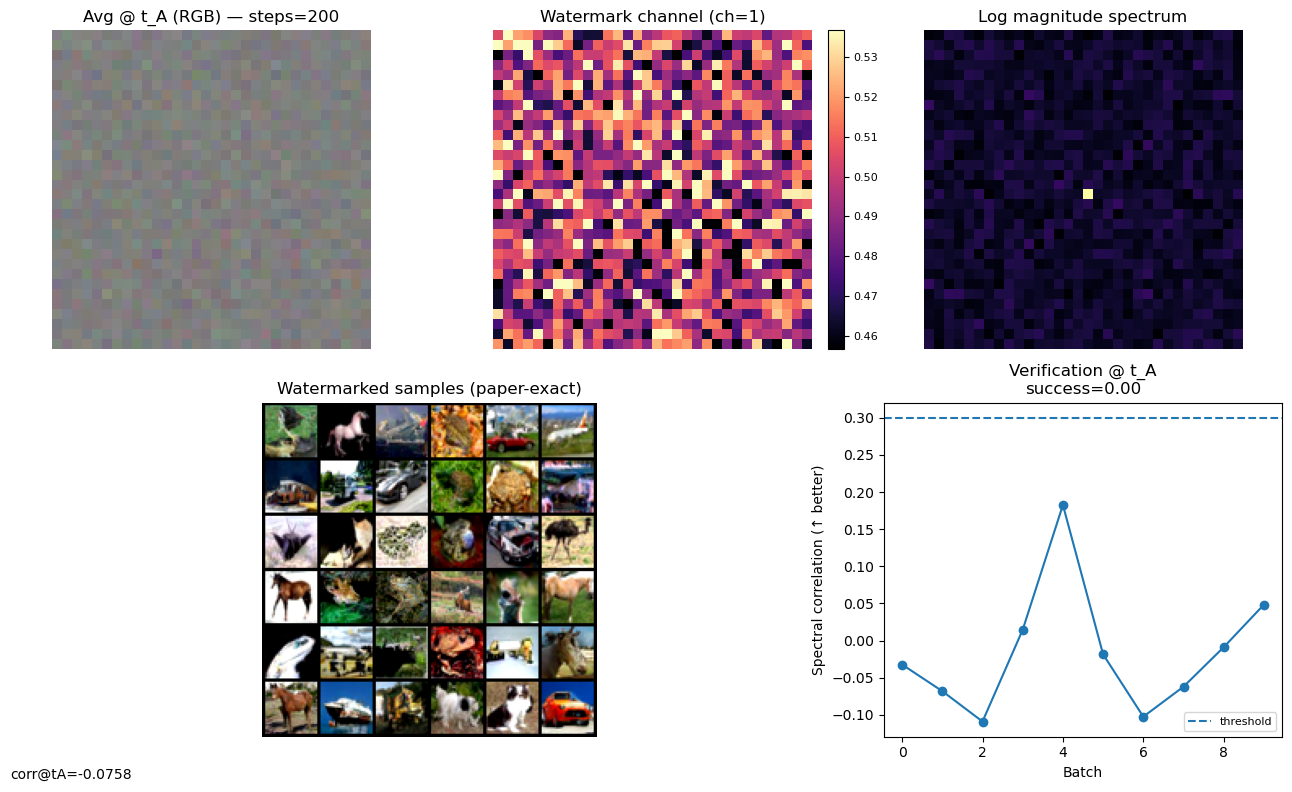

[DONE] 7) Build summary figure in 0.23s (cumulative 1204.90s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 870.88s (cumulative 2075.79s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2075.79s)

=== finetune_and_report done in 2075.79s ===
=== finetune_and_report start (max_steps=300) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 300 steps: 100%|██████████| 300/300 [01:13<00:00,  4.07it/s, loss=0.0566]


[DONE] 3) Run fine-tuning in 74.09s (cumulative 74.14s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 110.86s (cumulative 185.00s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 18.97s (cumulative 203.97s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1087.78s (cumulative 1291.75s)

[STEP] 7) Build summary figure ...


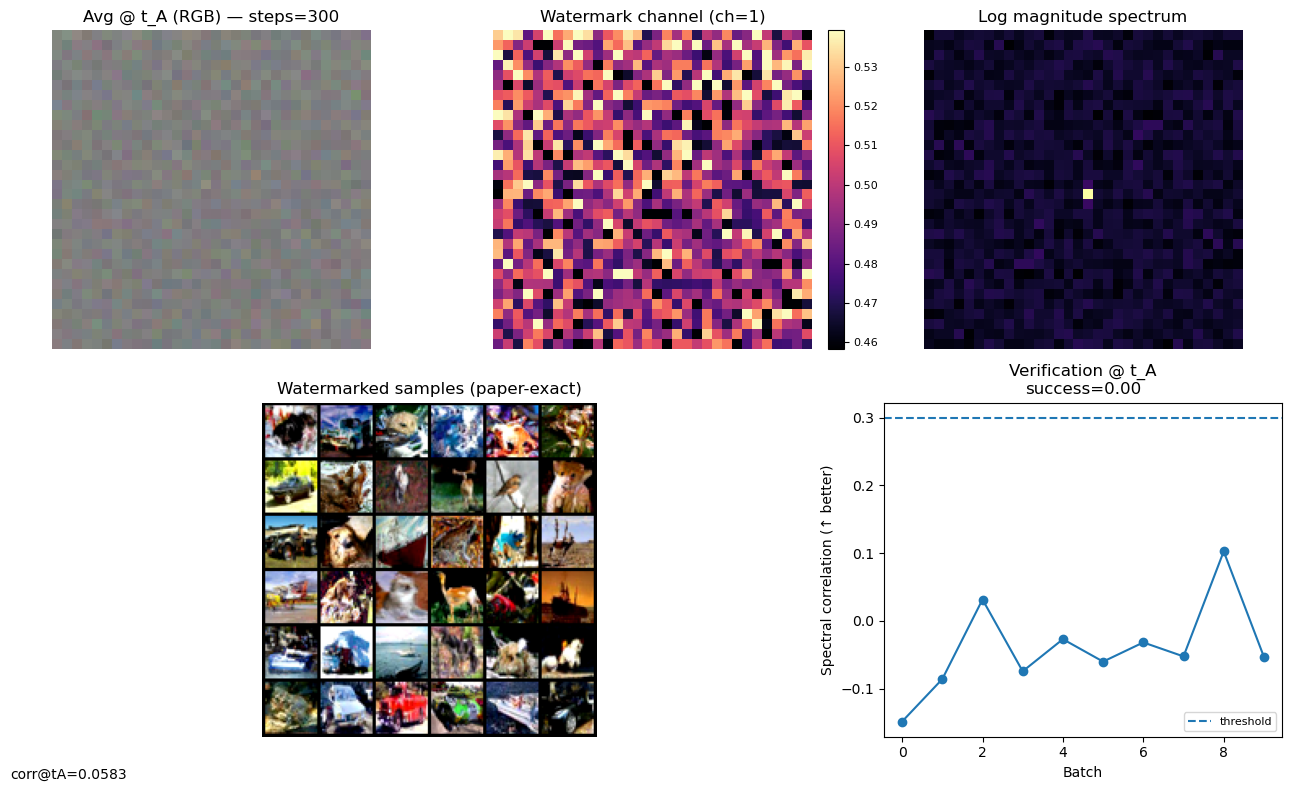

[DONE] 7) Build summary figure in 0.24s (cumulative 1291.99s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 867.67s (cumulative 2159.67s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2159.67s)

=== finetune_and_report done in 2159.67s ===
=== finetune_and_report start (max_steps=500) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 500 steps: 100%|██████████| 500/500 [01:50<00:00,  4.52it/s, loss=0.0911]


[DONE] 3) Run fine-tuning in 110.87s (cumulative 110.91s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 99.59s (cumulative 210.50s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 18.07s (cumulative 228.57s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 1025.69s (cumulative 1254.26s)

[STEP] 7) Build summary figure ...


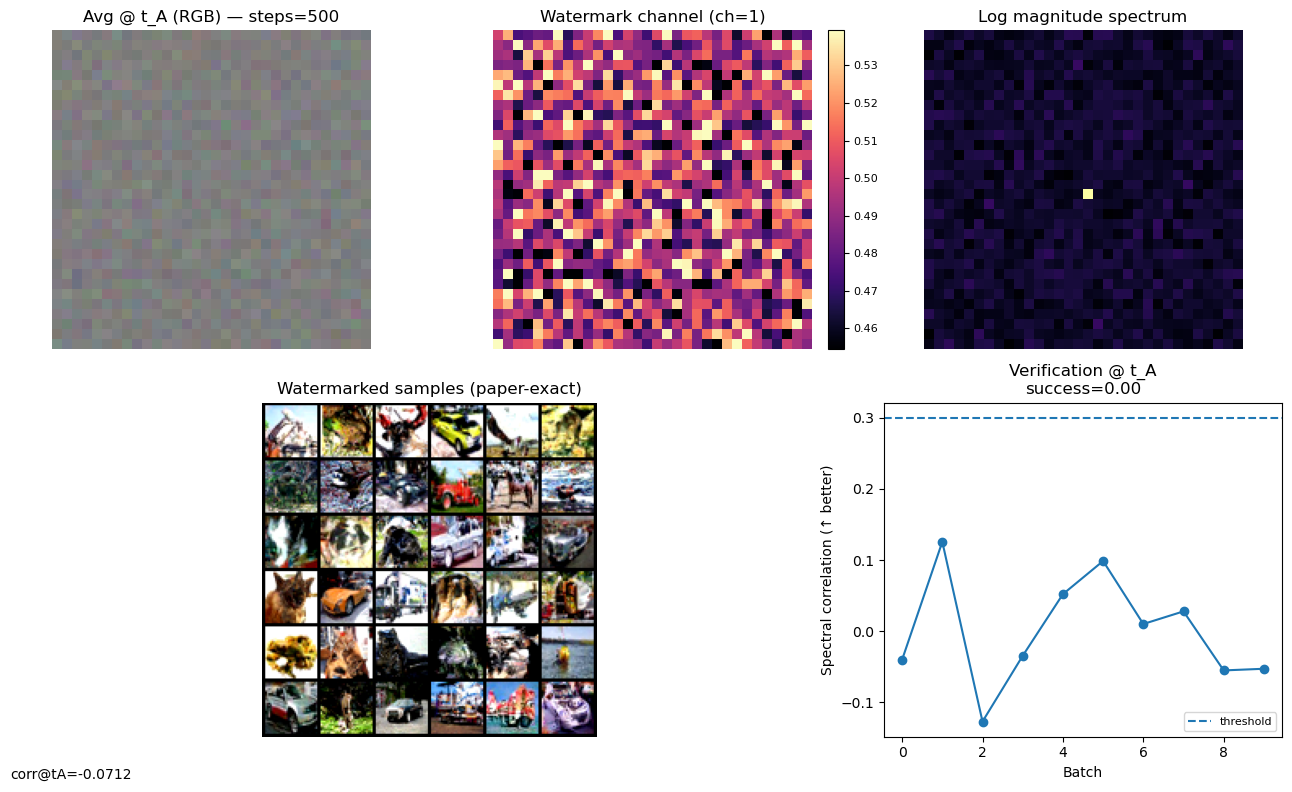

[DONE] 7) Build summary figure in 0.23s (cumulative 1254.49s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 863.23s (cumulative 2117.72s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2117.72s)

=== finetune_and_report done in 2117.72s ===
=== finetune_and_report start (max_steps=1000) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 1000 steps: 100%|██████████| 1000/1000 [03:56<00:00,  4.23it/s, loss=0.0451]


[DONE] 3) Run fine-tuning in 236.63s (cumulative 236.67s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 103.70s (cumulative 340.37s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 16.08s (cumulative 356.45s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 984.48s (cumulative 1340.93s)

[STEP] 7) Build summary figure ...


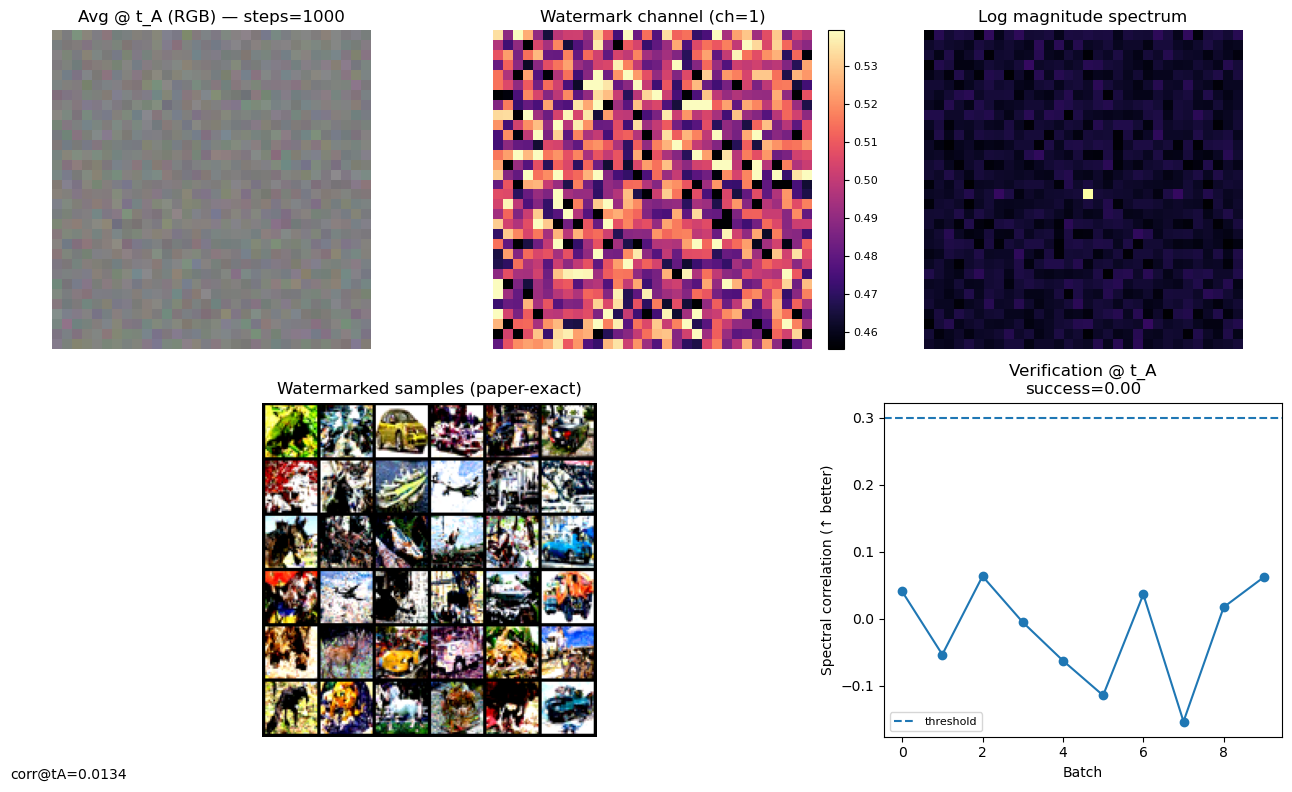

[DONE] 7) Build summary figure in 0.24s (cumulative 1341.18s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] IS failed: Unexpected keyword arguments: `num_splits`
[DONE] 8) Compute quality metrics (optional) in 799.32s (cumulative 2140.50s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 2140.50s)

=== finetune_and_report done in 2140.50s ===


,max_steps,spectral_corr_tA,verify_success,IS,FID,Precision,Recall
0,0,0.159665,0.0,None,35.996445,0.676758,0.620117
1,100,-0.056005,0.0,None,38.860500,0.660645,0.624023
2,200,-0.075844,0.0,None,43.285366,0.679199,0.556641
3,300,0.058262,0.0,None,49.452579,0.643066,0.561523
4,500,-0.071167,0.0,None,66.779251,0.631836,0.453125
5,1000,0.013395,0.0,None,113.717758,0.449707,0.330078


In [10]:
# ---------- Full fine-tuning loop ----------
def _run_finetune(
    work_unet, opt, ema_unet, ema_decay, max_steps: int, gamma: float
):
    """
    Fine-tune the UNet with biased batches (Algorithm 1) for 'max_steps'.
    This is the main training loop used before we evaluate watermark detectability.
    """
    work_unet.train()
    pbar = tqdm(range(max_steps), desc=f"Fine-tuning (Alg.1, f1=0) {max_steps} steps")
    data_iter = iter(train_loader)
    loss_traj = []

    for _ in pbar:
        # Get next batch (recycle loader if needed)
        try:
            x0, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x0, _ = next(data_iter)

        x0 = x0.to(device)
        B = x0.size(0)
        t = torch.randint(0, T, (B,), device=device, dtype=torch.long)

        # Build biased input/target for current timestep
        x_t_prime, eps_dblprime = _build_biased_batch(x0, t, gamma)

        # Forward + loss
        noise_pred = work_unet(x_t_prime, t, return_dict=False)[0]
        loss =  torch.nn.functional.mse_loss(noise_pred, eps_dblprime)

        # Backprop and update
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(work_unet.parameters(), 1.0)
        opt.step()

        # EMA update (optional)
        if ema_unet is not None:
            with torch.no_grad():
                for pe, p in zip(ema_unet.parameters(), work_unet.parameters()):
                    pe.mul_(ema_decay).add_(p, alpha=1.0 - ema_decay)

        loss_val = float(loss.detach().cpu())
        loss_traj.append(loss_val)
        pbar.set_postfix(loss=loss_val)

    # Return EMA model if available (for sampling), else the fine-tuned one
    sampler_unet = ema_unet if (ema_unet is not None and channels == 3) else work_unet
    sampler_unet.eval()
    return sampler_unet, loss_traj

# ---------- Small config resolver ----------
def _resolve_defaults(
    lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
    n_final_samples, contour_threshold  # kept name for backward-compat; now used as corr_threshold
):
    lr = cfg.lr if lr is None else lr
    gamma = cfg.gamma if gamma is None else gamma
    use_ema = (cfg.use_ema and channels == 3) if use_ema is None else use_ema
    verify_batches = cfg.verify_batches if verify_batches is None else verify_batches
    verify_batch_size = cfg.verify_batch_size if verify_batch_size is None else verify_batch_size
    sample_steps = cfg.sample_steps if sample_steps is None else sample_steps
    n_final_samples = cfg.n_final_samples if n_final_samples is None else n_final_samples
    corr_threshold = cfg.contour_threshold if contour_threshold is None else contour_threshold  # reinterpret as correlation threshold
    return (lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
            n_final_samples, corr_threshold)

# ---------- Model/opt/EMA prep ----------
def _prepare_models_and_opt(train_scope: str, lr: float, use_ema: bool):
    """Deep-copy baseline, unfreeze the requested scope, create optimizer and optional EMA."""
    work_unet = copy.deepcopy(baseline_unet).to(device)
    set_trainable(work_unet, mode=train_scope)

    # Optimizer over trainable params
    for p in work_unet.parameters():
        if p.requires_grad:
            p.requires_grad = True
    opt = torch.optim.AdamW(work_unet.parameters(), lr=lr, weight_decay=0.0)

    # Optional EMA for stable sampling
    ema_unet = None
    if use_ema:
        ema_unet = copy.deepcopy(work_unet).eval()
        for p in ema_unet.parameters():
            p.requires_grad = False
    ema_decay = 0.999
    return work_unet, opt, ema_unet, ema_decay

# ---------- One training step: build biased inputs/targets ----------
def _build_biased_batch(x0: torch.Tensor, t: torch.Tensor, gamma: float,
                        lam_clip: float = 0.02):
    """
    Algorithm 1 with Fourier-domain watermark injection:
      - For t <= tA: apply a small multiplicative magnitude modulation in FFT
        on the watermarked channel inside a mid-band annulus (ANNULUS) using PN.
      - For t > tA: construct a spectrally watermarked x'_{tA} once, then
        simulate forward to the desired t using ᾱ_t / ᾱ_{tA}.
    Target shift remains: ε'' = γ ε' + (1-γ) K x_A (for t <= tA).
    """
    import numpy as np

    B, C, H, W = x0.shape
    assert C > WTMK_CH, "WTMK_CH out of range for channels"

    # Base forward noising (simulate q(x_t | x0))
    eps_prime = torch.randn_like(x0)
    x_sim = scheduler.add_noise(x0, eps_prime, t)

    x_t_prime    = x_sim.clone()
    eps_dblprime = eps_prime.clone()

    # ---- helper: spectral magnitude modulation on one HxW array ----
    def _spectral_mod_one(x_hw: np.ndarray, lam: float) -> np.ndarray:
        Xi = np.fft.fftshift(np.fft.fft2(x_hw))
        mag, ph = np.abs(Xi), np.angle(Xi)
        # bounded multiplicative tweak (keep positivity)
        gain = np.ones_like(mag, dtype=np.float32)
        gain[ANNULUS] = (1.0 + np.clip(lam, -lam_clip, lam_clip) * PN[ANNULUS])
        mag2 = mag * gain
        Xi2 = np.fft.ifftshift(mag2 * np.exp(1j * ph))
        x_mod = np.fft.ifft2(Xi2).real.astype(np.float32)
        return x_mod

    # ---------- EMBEDDING stage: t <= tA ----------
    embed = (t <= tA)
    if embed.any():
        idx = embed.nonzero(as_tuple=False).squeeze(1)
        sqrt_ab_t  = (a_bar.index_select(0, t[idx]).view(-1,1,1,1)).sqrt()
        sqrt_1m_t  = (1 - a_bar.index_select(0, t[idx]).view(-1,1,1,1)).sqrt()
        f2_t       = f2.index_select(0, t[idx]).view(-1,1,1,1)

        # Baseline xt without spatial bias
        base_xt = sqrt_ab_t * x0[idx] + gamma * sqrt_1m_t * eps_prime[idx]
        x_mod = base_xt.clone()

        # Per-sample modulation strength following f2(t)
        lam_vec = ((1.0 - gamma) * f2_t.view(-1)).clamp(min=0.0).cpu().numpy()

        ch = WTMK_CH
        x_np = x_mod[:, ch].detach().cpu().numpy().astype(np.float32)  # [Be,H,W]
        for i in range(x_np.shape[0]):
            x_np[i] = _spectral_mod_one(x_np[i], lam=float(lam_vec[i]))
        x_mod[:, ch] = torch.from_numpy(x_np).to(x_mod.device)

        x_t_prime[idx] = x_mod
        # Target shift (teach UNet the watermark direction)
        eps_dblprime[idx] = gamma * eps_prime[idx] + (1.0 - gamma) * (K * xA)

    # ---------- SIMULATION stage: t > tA ----------
    sim = ~embed
    if sim.any():
        idx = sim.nonzero(as_tuple=False).squeeze(1)
        B2 = idx.numel()
        tA_tensor = torch.full((B2,), tA, device=x0.device, dtype=torch.long)

        sqrt_ab_tA  = (a_bar.index_select(0, tA_tensor).view(-1,1,1,1)).sqrt()
        sqrt_1m_tA  = (1 - a_bar.index_select(0, tA_tensor).view(-1,1,1,1)).sqrt()
        f2_tA       = f2.index_select(0, tA_tensor).view(-1,1,1,1)

        # Build x'_{tA} and apply spectral modulation at tA
        eps_prime_tA = torch.randn_like(x0[idx])
        x_tA_base = sqrt_ab_tA * x0[idx] + gamma * sqrt_1m_tA * eps_prime_tA
        x_tA_mod  = x_tA_base.clone()

        lam_vecA = ((1.0 - gamma) * f2_tA.view(-1)).clamp(min=0.0).cpu().numpy()
        ch = WTMK_CH
        x_np = x_tA_mod[:, ch].detach().cpu().numpy().astype(np.float32)
        for i in range(x_np.shape[0]):
            x_np[i] = _spectral_mod_one(x_np[i], lam=float(lam_vecA[i]))
        x_tA_mod[:, ch] = torch.from_numpy(x_np).to(x_tA_mod.device)

        # Simulate distributionally from tA -> t
        ratio = (a_bar.index_select(0, t[idx]).view(-1,1,1,1) / a_bar[tA]).clamp(min=1e-12)
        x_t_prime[idx] = ratio.sqrt() * x_tA_mod + (1.0 - ratio).sqrt() * eps_prime[idx]

        # No target shift for t>tA
        eps_dblprime[idx] = eps_prime[idx]

    return x_t_prime, eps_dblprime

# ---------- Detection: average at t_A & correlation (↑ better) ----------
@torch.no_grad()
def _detect_at_tA(sampler_unet, sample_steps: int, gamma: float):
    """
    Return:
      xavg: [1,C,H,W] float in [0,1]
      xavg_u8: [C,H,W] uint8
      ch: watermark channel as np.float32
      (lo, hi): percentiles for heatmap
      dist_mask_dummy: kept for API compatibility (unused here)
      corr_tA: spectral correlation score (↑ better)
    """
    xmid = _sample_mid_after(sampler_unet, scheduler, n=cfg.verify_batch_size,
                             steps=sample_steps, capture_tA=tA, gamma=gamma)
    xavg = xmid.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]
    xavg_u8 = to_u8(xavg)[0]
    ch = xavg[0, WTMK_CH].cpu().numpy().astype(np.float32)
    lo, hi = np.percentile(ch, [5, 95]); 
    if hi <= lo: hi = lo + 1e-3

    # Compute spectral correlation (expects float [C,H,W] in [0,1])
    corr_tA = float(spectral_correlation_score(xavg[0], PN, ANNULUS))
    return xavg, xavg_u8, ch, (lo, hi), None, corr_tA

# ---------- Verification: multiple averages under paper-exact sampling ----------
@torch.no_grad()
def _verify_batches(sampler_unet, sample_steps: int, gamma: float,
                    batches: int, batch_size: int, threshold: float):
    """
    Repeat averaging at t_A and compute spectral correlation across 'batches' trials.
    Success := correlation >= threshold  (since ↑ is better).
    """
    corrs = []
    for _ in range(batches):
        _, xmid_ = sample_paper(sampler_unet, scheduler, n=batch_size,
                                steps=sample_steps, capture_tA=tA, gamma=gamma)
        xavg_ = xmid_.mean(dim=0, keepdim=True)
        corr = float(spectral_correlation_score(xavg_[0], PN, ANNULUS))
        corrs.append(corr)
    arr = np.array(corrs, dtype=np.float32)
    success = float((arr >= threshold).mean())
    return arr, success

# ---------- Visualization ----------
def _build_summary_figure(max_steps: int, xavg, ch, lo, hi,
                          grid_np, correlations, corr_threshold, corr_tA, _unused):
    """
    Compose the one-page report figure.
    Note: Plot shows spectral correlation (↑ better). Threshold line = minimum acceptable correlation.
    """
    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.05])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0:2])
    ax5 = fig.add_subplot(gs[1, 2])

    # (1) Avg RGB @ t_A
    ax1.imshow(xavg[0].permute(1, 2, 0).cpu().numpy())
    ax1.set_title(f"Avg @ t_A (RGB) — steps={max_steps}")
    ax1.axis("off")

    # (2) Watermark channel heatmap
    im2 = ax2.imshow(ch, cmap="magma", vmin=lo, vmax=hi)
    ax2.set_title(f"Watermark channel (ch={WTMK_CH})")
    ax2.axis("off")
    cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

    # (3) Simple magnitude spectrum (for intuition, optional)
    F = np.fft.fftshift(np.fft.fft2(ch))
    ax3.imshow(np.log1p(np.abs(F)), cmap="inferno")
    ax3.set_title("Log magnitude spectrum")
    ax3.axis("off")

    # (4) Final sample grid
    ax4.imshow(grid_np)
    ax4.set_title("Watermarked samples (paper-exact)")
    ax4.axis("off")

    # (5) Spectral correlation across verification batches
    xs = np.arange(len(correlations))
    ax5.plot(xs, correlations, marker='o')
    ax5.axhline(corr_threshold, linestyle='--', label='threshold')
    ax5.set_xlabel("Batch")
    ax5.set_ylabel("Spectral correlation (↑ better)")
    ax5.set_title(f"Verification @ t_A\nsuccess={(correlations >= corr_threshold).mean():.2f}")
    ax5.legend(loc="best", fontsize=8)

    fig.text(0.01, 0.02, f"corr@tA={corr_tA:.4f}", fontsize=10)
    fig.tight_layout()
    return fig

# ---------- Optional: quality metrics (IS/FID/Precision/Recall) ----------
# ---------- Optional: quality metrics (IS/FID/Precision/Recall) ----------
# Key ideas:
#  - Use a held-out real_loader (val/test), not the training loader.
#  - Cache real Inception stats (mu, sigma) so you don't recompute every run.
#  - Stream generated features in batches and compute FID from (mu_g, Sigma_g).
#  - IS is computed on generated images only; Precision/Recall is optional (slow).

import os
import math
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def _resize299_uint8_to_float(img_u8: torch.Tensor) -> torch.Tensor:
    """
    img_u8: (B,C,H,W) uint8 [0..255] on CPU/GPU.
    Returns float32 tensor in [0,1], (B,C,299,299), on same device.
    """
    x = img_u8
    if x.dtype != torch.uint8:
        raise ValueError("Expected uint8 input.")
    x = x.float() / 255.0
    x = torch.nn.functional.interpolate(x, size=299, mode="bilinear", align_corners=False, antialias=True)
    return x

@torch.no_grad()
def _inception_pool3_feats(
    imgs_u8: torch.Tensor,
    inception_model,          # a frozen InceptionV3 returning 2048-d pool3
    batch_size: int = 64,
    use_autocast: bool = True,
) -> np.ndarray:
    """
    Compute 2048-d Inception (pool3) activations for a uint8 image tensor.
    Returns np.ndarray (N,2048) on CPU.
    """
    device = next(inception_model.parameters()).device
    feats_list = []
    N = imgs_u8.shape[0]
    for i in range(0, N, batch_size):
        chunk = imgs_u8[i:i+batch_size].to(device, non_blocking=True)
        chunk = _resize299_uint8_to_float(chunk)
        # keep activation in fp32 for compatibility with cached real stats
        if use_autocast and torch.cuda.is_available():
            with torch.autocast("cuda"):
                f = inception_model(chunk)              # (b,2048)
        else:
            f = inception_model(chunk)
        feats_list.append(f.float().cpu().numpy())
    return np.concatenate(feats_list, axis=0)

def _save_stats_npz(path, mu, sigma):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    np.savez(path, mu=mu, sigma=sigma)

def _load_stats_npz(path):
    arr = np.load(path)
    return arr["mu"], arr["sigma"]

def _frechet_distance(mu1, sigma1, mu2, sigma2):
    # standard FID formula
    from scipy import linalg
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2.0 * covmean))

def _collect_real_feats_or_cache(
    real_loader,                        # iter of (img_u8, ...) with uint8 images in [0..255]
    inception_model,
    max_real: int,
    cache_path: str | None = None,
    batch_size: int = 128,
    use_autocast: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns (mu_real, sigma_real). Uses cache if provided and exists.
    """
    if cache_path and os.path.exists(cache_path):
        return _load_stats_npz(cache_path)

    # Collect up to max_real real images into one tensor (batches to save memory).
    imgs = []
    n_collected = 0
    for batch in real_loader:
        # allow loaders to return (img, label) or dicts
        if isinstance(batch, (list, tuple)):
            img_u8 = batch[0]
        elif isinstance(batch, dict):
            img_u8 = batch["image"]
        else:
            img_u8 = batch
        if img_u8.dtype != torch.uint8:
            # if your loader gives float [0,1], convert to uint8 once here
            img_u8 = (img_u8.clamp(0,1)*255).to(torch.uint8)
        imgs.append(img_u8)
        n_collected += img_u8.shape[0]
        if n_collected >= max_real:
            break
    if not imgs:
        raise ValueError("real_loader yielded no images.")
    real_u8 = torch.cat(imgs, dim=0)[:max_real]    # (Nr,C,H,W) uint8

    feats = _inception_pool3_feats(real_u8, inception_model, batch_size=batch_size, use_autocast=use_autocast)
    mu = feats.mean(axis=0)
    sigma = np.cov(feats, rowvar=False)
    if cache_path:
        _save_stats_npz(cache_path, mu, sigma)
    return mu, sigma

@torch.no_grad()
def _generate_feats_streaming(
    sampler_unet, scheduler, num_gen: int, sample_steps: int, gamma: float,
    inception_model, batch_size_gen: int = 32, batch_size_feat: int = 64,
    use_autocast: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate num_gen images in batches; compute Inception feats on the fly; return (mu_g, cov_g).
    """
    device_inception = next(inception_model.parameters()).device
    feats_list = []
    done = 0
    while done < num_gen:
        n = min(batch_size_gen, num_gen - done)
        # Generate n samples (uint8) — modify _generate_u8 if needed to accept n
        # Expect [n,C,H,W] uint8 on CPU or GPU; if float, convert to uint8 once.
        imgs_u8 = _generate_u8(sampler_unet, scheduler, n, steps=sample_steps, gamma=gamma)  # uint8

        # Inception feats
        feats = _inception_pool3_feats(
            imgs_u8.to(device_inception, non_blocking=True),
            inception_model,
            batch_size=batch_size_feat,
            use_autocast=use_autocast,
        )
        feats_list.append(feats)
        done += n

    feats_all = np.concatenate(feats_list, axis=0)
    mu = feats_all.mean(axis=0)
    sigma = np.cov(feats_all, rowvar=False)
    return mu, sigma

def _compute_quality_metrics_if_requested(
    compute_metrics: bool,
    sampler_unet,
    sample_steps: int,
    gamma: float,
    metrics_num_gen: int,
    metrics_num_real: int,
    metrics_splits: int,
    *,
    # NEW: pass a held-out loader and an inception model
    real_loader,                   # REQUIRED: val/test loader (not train)
    inception_model,               # REQUIRED: returns 2048-d pool3
    scheduler=None,
    cache_dir: str = "./metrics_cache",
    cache_tag: str = "val",        # part of filename to distinguish splits
    do_is: bool = False,
    do_fid: bool = True,
    do_pr: bool = False,           # Precision/Recall is slow, keep False unless needed
    gen_batch_size: int = 32,
    feat_batch_size: int = 128,
    use_autocast: bool = True,
):
    """
    Faster & cleaner metrics:
      - Uses held-out real_loader.
      - Caches real (mu, sigma) for FID under cache_dir/fid_stats_{cache_tag}.npz
      - Streams generated feats; avoids storing all images at once.
      - IS optional; PR optional (recommended: off).
    """
    metrics = {"IS": None, "FID": None, "Precision": None, "Recall": None}
    if not compute_metrics:
        return metrics

    if real_loader is None:
        print("[warn] real_loader=None; cannot compute metrics.")
        return metrics
    if inception_model is None:
        print("[warn] inception_model=None; cannot compute metrics.")
        return metrics

    # 1) Real stats (cached)
    mu_real = sigma_real = None
    if do_fid or do_pr:
        os.makedirs(cache_dir, exist_ok=True)
        cache_path = os.path.join(cache_dir, f"fid_stats_{cache_tag}.npz")
        try:
            mu_real, sigma_real = _collect_real_feats_or_cache(
                real_loader,
                inception_model,
                max_real=metrics_num_real,
                cache_path=cache_path,
                batch_size=feat_batch_size,
                use_autocast=use_autocast,
            )
        except Exception as e:
            print(f"[warn] collecting real feats failed: {e}")
            return metrics

    # 2) Generated stats (streaming)
    mu_gen = sigma_gen = None
    if do_fid or do_pr:
        try:
            mu_gen, sigma_gen = _generate_feats_streaming(
                sampler_unet, scheduler, metrics_num_gen, sample_steps, gamma,
                inception_model,
                batch_size_gen=gen_batch_size,
                batch_size_feat=feat_batch_size,
                use_autocast=use_autocast,
            )
        except Exception as e:
            print(f"[warn] generating feats failed: {e}")
            return metrics

    # 3) FID
    if do_fid and (mu_real is not None):
        try:
            metrics["FID"] = _frechet_distance(mu_gen, sigma_gen, mu_real, sigma_real)
        except Exception as e:
            print(f"[warn] FID computation failed: {e}")

    # 4) Inception Score (optional; on generated only)
    if do_is:
        try:
            from torchmetrics.image.inception import InceptionScore
            # IS expects float [0,1] images sized for Inception; do on-the-fly batches
            is_metric = InceptionScore(num_splits=max(1, metrics_splits), normalize=False).to(
                next(inception_model.parameters()).device
            )
            done = 0
            while done < metrics_num_gen:
                n = min(gen_batch_size, metrics_num_gen - done)
                imgs_u8 = _generate_u8(sampler_unet, scheduler, n, steps=sample_steps, gamma=gamma)
                imgs = _resize299_uint8_to_float(imgs_u8.to(is_metric.device, non_blocking=True))
                is_metric.update(imgs)
                done += n
            IS_mean, IS_std = is_metric.compute()
            metrics["IS"] = (float(IS_mean), float(IS_std))
        except Exception as e:
            print(f"[warn] IS failed: {e}")

    # 5) Precision/Recall (optional, slow unless you use FAISS)
    if do_pr:
        try:
            # If you want PR, compute once using FAISS-GPU on (feats_gen vs feats_real)
            # feats_real could be cached to disk too to avoid recompute.
            # Placeholder: you can plug in your _precision_recall_knn or FAISS version.
            pass
        except Exception as e:
            print(f"[warn] Precision/Recall failed: {e}")

    return metrics




# ----------------------------------------------------------------------------- 
# Main: Fine-tune the model and produce ONE combined figure summarizing the run
# -----------------------------------------------------------------------------
import time
import traceback
from typing import Tuple

def finetune_and_report(
    max_steps: int,
    *,
    lr: float = None,
    gamma: float = None,
    use_ema: bool = None,
    verify_batches: int = None,
    verify_batch_size: int = None,
    sample_steps: int = None,
    n_final_samples: int = None,
    contour_threshold: float = None,   # interpreted as correlation threshold now
    return_models: bool = False,
    show: bool = True,
    train_scope: str = "all",          # {"all","last_conv","last_block","last_two_blocks"}
    compute_metrics: bool = True,
    metrics_num_gen: int = 2048,
    metrics_num_real: int = 2048,
    metrics_splits: int = 10,
):
    """
    Instrumented version: prints progress + wall-clock time for each major block.
    If any block errors, the function prints the step name and re-raises the exception.
    """
    def _now() -> float:
        return time.perf_counter()

    def _print_step_header(step_name: str):
        print(f"\n[STEP] {step_name} ...", flush=True)

    def _print_step_done(step_name: str, t_start: float, t0_global: float):
        dt = _now() - t_start
        dt_total = _now() - t0_global
        print(f"[DONE] {step_name} in {dt:.2f}s (cumulative {dt_total:.2f}s)", flush=True)

    t0_global = _now()
    print(f"=== finetune_and_report start (max_steps={max_steps}) ===", flush=True)

    timings = {}  # optional: keep raw timings per step

    # 1) Defaults
    step = "1) Resolve defaults"
    _print_step_header(step)
    t = _now()
    try:
        (lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
         n_final_samples, corr_threshold) = _resolve_defaults(
            lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
            n_final_samples, contour_threshold
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 2) Prep models/opt/EMA
    step = "2) Prepare models/optimizer/EMA"
    _print_step_header(step)
    t = _now()
    try:
        work_unet, opt, ema_unet, ema_decay = _prepare_models_and_opt(train_scope, lr, use_ema)
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 3) Fine-tune
    step = "3) Run fine-tuning"
    _print_step_header(step)
    t = _now()
    try:
        sampler_unet, loss_traj = _run_finetune(
            work_unet, opt, ema_unet, ema_decay, max_steps, gamma
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 4) Detect watermark at t_A (avg) -> spectral correlation
    step = "4) Detect watermark at t_A (spectral correlation)"
    _print_step_header(step)
    t = _now()
    try:
        xavg, xavg_u8, ch, (lo, hi), _mask_unused, corr_tA = _detect_at_tA(
            sampler_unet, sample_steps=sample_steps, gamma=gamma
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 5) Final samples (quality eyeballing)
    step = "5) Generate final samples"
    _print_step_header(step)
    t = _now()
    try:
        imgs_wtmk, _ = sample_paper(
            sampler_unet, scheduler, n=n_final_samples,
            steps=sample_steps, capture_tA=tA, gamma=gamma
        )
        grid = make_grid(imgs_wtmk, nrow=int(np.sqrt(n_final_samples)), padding=2)
        grid_np = (grid.detach().cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 6) Verification batches (Spectral correlation ONLY)
    step = "6) Verify batches (spectral correlation)"
    _print_step_header(step)
    t = _now()
    try:
        correlations, success = _verify_batches(
            sampler_unet, sample_steps=sample_steps, gamma=gamma,
            batches=verify_batches, batch_size=verify_batch_size,
            threshold=corr_threshold
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 7) Figure
    step = "7) Build summary figure"
    _print_step_header(step)
    t = _now()
    try:
        fig = _build_summary_figure(
            max_steps, xavg, ch, lo, hi, grid_np, correlations, corr_threshold, corr_tA, None
        )
        if show:
            plt.show()
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 8) Optional quality metrics (IS/FID/Precision/Recall)
    step = "8) Compute quality metrics (optional)"
    _print_step_header(step)
    t = _now()
    try:
        metrics = _compute_quality_metrics_if_requested(
            compute_metrics, sampler_unet, sample_steps, gamma,
            metrics_num_gen, metrics_num_real, metrics_splits
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 9) Results dict (+ optional models)
    step = "9) Assemble results"
    _print_step_header(step)
    t = _now()
    try:
        result = {
            "max_steps": max_steps,
            "loss_traj": loss_traj,
            "xavg_tA": xavg,                         # [1,C,H,W] in [0,1]
            "samples": imgs_wtmk,                    # [N,C,H,W] in [0,1]
            "spectral_corr_tA": corr_tA,             # ↑ better
            "verify_correlations": correlations,     # np.array of correlations
            "verify_success": float(success),        # fraction >= threshold
            **metrics,                               # IS/FID/Precision/Recall (may be None)
            "timings": timings,                      # include raw per-step timings
            "total_time_sec": _now() - t0_global,    # total runtime
        }
        if return_models:
            result.update({
                "unet": work_unet,
                "ema_unet": ema_unet,
                "sampler_unet": sampler_unet
            })
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)

    total = _now() - t0_global
    print(f"\n=== finetune_and_report done in {total:.2f}s ===", flush=True)
    return result, fig


print("Running fine-tuning sweep (all layers) + attacks…")
results = []
attack_rows = []  # long-form per-attack table

for steps in cfg.finetune_sweep:
    res, fig = finetune_and_report(steps, show=True, train_scope="all", return_models=False)
    results.append(res)

# High-level summary per run
summary_cols = ["max_steps", "spectral_corr_tA", "verify_success", "IS", "FID", "Precision", "Recall"]
df_all = pd.DataFrame(results)
display(df_all[[c for c in summary_cols if c in df_all.columns]])

print("Running fine-tuning sweep (last block only) + attacks…")
last_block_results = []
for steps in cfg.finetune_sweep:
    res, fig = finetune_and_report(steps, train_scope="last_block", show=True, return_models=False)
    last_block_results.append(res)

df_last = pd.DataFrame(last_block_results)
display(df_last[[c for c in summary_cols if c in df_last.columns]])